# Cloud-Native Intrusion Detection with Gaussian Anomaly Detection

**Course:** AI for Cybersecurity — Module 1 Lab
**Dataset:** CIC-IDS-2017, Canadian Institute for Cybersecurity, University of New Brunswick
**Method:** Multivariate Gaussian anomaly detection (Parisi, 2019, Ch. 5), extended to a Gaussian
Mixture Model and benchmarked against Isolation Forest
**Current trend:** cloud-native IDS / detection-as-code

---

### The design decision that drives this whole notebook

This is **semi-supervised anomaly detection**, not supervised classification.

The model is fitted on **benign traffic only**. It never sees a single attack during training.
Anything that then falls into a low-probability region of the learned benign distribution is
flagged as an intrusion.

That choice is deliberate, and it is the reason the notebook is built this way:

1. **It matches how detection actually works in production.** A SOC has effectively unlimited
   benign traffic and almost no labelled attacks. A supervised classifier trained on
   CIC-IDS-2017's fifteen labelled classes would score beautifully here and fail on the first
   attack family that isn't in the label set.
2. **It generalises to unseen attacks.** Because the model only encodes "what normal looks
   like", a zero-day that deviates from normal is detectable without ever having been labelled.
3. **It is exactly the Chapter 5 method.** Parisi (2019) builds the anomaly detector by
   estimating the density of normal traffic and thresholding the likelihood.

The labels are used for **evaluation only** — and, in one controlled place, to choose the
decision threshold on a validation split. They are never used to fit the density model.

### What the notebook does

| Step | Section |
|---|---|
| Load all eight CIC-IDS-2017 capture files | 2 |
| Audit raw data quality before touching it | 3 |
| Clean: whitespace, duplicate column, infinities, NaN, constants, duplicate rows, corrupt labels | 4 |
| Explore class balance and benign-vs-attack feature behaviour | 5 |
| Engineer features: variance-stabilising transform, collinearity prune, Gaussianisation | 6 |
| Split semi-supervised (benign-only training set) | 7 |
| Fit a multivariate Gaussian from scratch | 8 |
| Choose the threshold ε on validation data | 9 |
| Extend to a Gaussian Mixture Model, selecting k on validation | 10 |
| Benchmark against Isolation Forest | 11 |
| Evaluate on the held-out test split | 12 |
| Choose a deployable operating point | 13 |
| Break detection down by attack family | 14 |
| Visualise the decision surface with PCA | 15 |
| Summary, trend, conclusion, references | 16–18 |

## 1. Environment and configuration

Colab ships every library used here. The `pip install` line is left commented for the case
where a runtime is missing something.

All randomness is seeded through `RANDOM_STATE` so the notebook reproduces exactly.

In [7]:
# !pip -q install pandas numpy scikit-learn matplotlib seaborn scipy

import os
import glob
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from scipy.linalg import cho_factor, cho_solve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix, roc_curve,
    roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report,
)

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------------
# Reproducibility + run configuration
# ----------------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE)

MAX_ROWS      = None      # None = use the full cleaned corpus. Set e.g. 500_000 for a fast pass.
CORR_CUTOFF   = 0.95      # drop a feature collinear with one already kept above this |r|
GMM_K_GRID    = (1, 2, 4, 6, 8, 10, 12, 16, 20)   # k=1 is the plain single Gaussian
GMM_FIT_ROWS  = 300_000   # rows subsampled from the benign training split to fit each GMM
TARGET_FPR    = 0.01      # the SOC-realistic operating point in section 13

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {mpl.__version__}")

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


### 1.1 Plot styling

Every figure in this notebook is drawn through one shared style so the results read as a single
system rather than nine unrelated charts. The rules applied:

* **Colour is assigned by the job it does**, not picked per chart. Categorical identity
  (benign vs attack, one model vs another) uses a fixed hue order. Magnitude (a confusion
  matrix, an anomaly score) uses a single-hue light→dark ramp. Polarity (a correlation, which
  runs −1…+1) uses a two-hue diverging ramp with a neutral grey midpoint.
* **The categorical hues are colour-vision-deficiency safe.** The three-slot order below was
  checked for protanopia/deuteranopia separation rather than chosen by eye.
* **Identity is never carried by colour alone** — every multi-series chart also carries a
  legend and, where it fits, a direct label on the line itself.
* **Grid and axes recede**; the data is the only thing with contrast.

In [8]:
# ----------------------------------------------------------------------------------
# Colour roles. Categorical slots are used in fixed order and never cycled.
# ----------------------------------------------------------------------------------
C_BENIGN  = "#2a78d6"   # slot 1, blue
C_ATTACK  = "#eb6834"   # slot 2, orange
C_THIRD   = "#1baf7a"   # slot 3, aqua  (always direct-labelled: it sits under 3:1 on white)
CATEGORICAL = [C_BENIGN, C_ATTACK, C_THIRD]

INK       = "#0b0b0b"   # primary text
INK_SOFT  = "#52514e"   # secondary text
GRID      = "#e3e2de"
SURFACE   = "#fcfcfb"

# Sequential ramp (magnitude): one hue, light -> dark.
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"])
# Diverging ramp (polarity): two hues + neutral grey midpoint.
DIV_BR = LinearSegmentedColormap.from_list(
    "div_br", ["#104281", "#3987e5", "#9ec5f4", "#f0efec", "#f3a58c", "#e34948", "#8f2220"])

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "font.size":         10.5,
    "axes.titlesize":    12.5,
    "axes.titleweight":  "semibold",
    "axes.titlelocation":"left",
    "axes.titlepad":     10,
    "axes.labelsize":    10,
    "axes.labelcolor":   INK_SOFT,
    "axes.edgecolor":    GRID,
    "axes.linewidth":    1.0,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "text.color":        INK,
    "xtick.color":       INK_SOFT,
    "ytick.color":       INK_SOFT,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "legend.frameon":    False,
    "legend.fontsize":   9.5,
    "lines.linewidth":   2.0,
    "lines.solid_capstyle": "round",
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, xgrid=False, ygrid=True):
    """Apply the shared chart anatomy: title, optional deck, axis labels, recessive grid."""
    # The deck sits between the title and the axes, so the title needs extra pad
    # reserved for it -- otherwise tight_layout overlaps the two.
    if title:
        ax.set_title(title, color=INK, pad=30 if sub else 10)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5,
                color=INK_SOFT, va="bottom", ha="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.xaxis.grid(xgrid); ax.yaxis.grid(ygrid)
    return ax

print("plot style ready")

plot style ready


## 2. Loading the dataset

CIC-IDS-2017 is distributed by UNB as `MachineLearningCSV.zip`: eight labelled CSVs covering one
working week of traffic, generated in a testbed that replays realistic user-behaviour profiles
against a scripted attack schedule (Sharafaldin, Lashkari & Ghorbani, 2018).

| File | Day | Attack activity |
|---|---|---|
| `Monday-WorkingHours` | Mon | none — pure benign baseline |
| `Tuesday-WorkingHours` | Tue | FTP-Patator, SSH-Patator (brute force) |
| `Wednesday-workingHours` | Wed | DoS Hulk / GoldenEye / slowloris / Slowhttptest, Heartbleed |
| `Thursday-…-WebAttacks` | Thu am | Web brute force, XSS, SQL injection |
| `Thursday-…-Infilteration` | Thu pm | Infiltration |
| `Friday-…-Morning` | Fri am | Bot |
| `Friday-…-PortScan` | Fri pm | PortScan |
| `Friday-…-DDos` | Fri pm | DDoS |

**To run this on Colab:**

1. Download `MachineLearningCSV.zip` from <https://www.unb.ca/cic/datasets/ids-2017.html>
2. Either put it in your Google Drive, or upload it when the cell below prompts you.
3. Run the cell. It unzips to `/content/cicids` and caches, so a re-run is instant.

The resolver below checks, in order: an explicit `CICIDS_DIR` environment variable, common local
paths, `/content`, and Google Drive — and only falls back to an interactive upload if none hit.
This keeps the notebook runnable both locally and in Colab without edits.

In [9]:
def _has_csvs(d):
    return bool(d) and os.path.isdir(d) and len(glob.glob(os.path.join(d, "**", "*.csv"), recursive=True)) > 0

def resolve_data_dir():
    """Locate the CIC-IDS-2017 CSVs, unzipping or prompting for upload if required."""
    candidates = [
        os.environ.get("CICIDS_DIR"),
        "MachineLearningCVE", "data/MachineLearningCVE",
        "/content/cicids/MachineLearningCVE", "/content/cicids",
        "/content/MachineLearningCVE",
        "/content/drive/MyDrive/cicids2017/MachineLearningCVE",
        "/content/drive/MyDrive/MachineLearningCVE",
    ]
    for c in candidates:
        if _has_csvs(c):
            return c

    # Not found as loose CSVs -- look for the distributed zip and expand it.
    zips = [z for z in ["MachineLearningCSV.zip", "/content/MachineLearningCSV.zip",
                        "/content/drive/MyDrive/MachineLearningCSV.zip"] if os.path.exists(z)]
    if not zips:
        try:                                      # Colab: offer Drive, then a manual upload
            from google.colab import drive, files
            if not os.path.exists("/content/drive"):
                drive.mount("/content/drive")
            for c in ["/content/drive/MyDrive/cicids2017/MachineLearningCVE",
                      "/content/drive/MyDrive/MachineLearningCVE"]:
                if _has_csvs(c):
                    return c
            for z in ["/content/drive/MyDrive/MachineLearningCSV.zip"]:
                if os.path.exists(z): zips = [z]; break
            if not zips:
                print("Upload MachineLearningCSV.zip when prompted ...")
                up = files.upload()
                zips = [k for k in up if k.endswith(".zip")]
        except Exception as exc:
            raise FileNotFoundError(
                "CIC-IDS-2017 CSVs not found. Set CICIDS_DIR, or place MachineLearningCSV.zip "
                "beside this notebook / in Google Drive."
            ) from exc

    os.makedirs("/content/cicids" if os.path.isdir("/content") else "cicids", exist_ok=True)
    dest = "/content/cicids" if os.path.isdir("/content") else "cicids"
    import zipfile
    with zipfile.ZipFile(zips[0]) as zf:
        zf.extractall(dest)
    for c in [os.path.join(dest, "MachineLearningCVE"), dest]:
        if _has_csvs(c):
            return c
    raise FileNotFoundError("Unzipped the archive but found no CSVs inside it.")

DATA_DIR = resolve_data_dir()
CSV_PATHS = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
print(f"data directory : {DATA_DIR}")
print(f"capture files  : {len(CSV_PATHS)}")
for p in CSV_PATHS:
    print(f"   {os.path.basename(p)[:58]:60s} {os.path.getsize(p)/1e6:7.1f} MB")
assert len(CSV_PATHS) == 8, f"expected 8 CIC-IDS-2017 CSVs, found {len(CSV_PATHS)}"

data directory : cicids/MachineLearningCVE
capture files  : 8
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                77.1 MB
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv            76.9 MB
   Friday-WorkingHours-Morning.pcap_ISCX.csv                       58.3 MB
   Monday-WorkingHours.pcap_ISCX.csv                              176.9 MB
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.cs      83.1 MB
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv          52.0 MB
   Tuesday-WorkingHours.pcap_ISCX.csv                             135.1 MB
   Wednesday-workingHours.pcap_ISCX.csv                           225.2 MB


## 3. Raw data audit — look before you clean

Preprocessing decisions should follow from measured defects, not from habit. This section reads
every file and counts exactly what is wrong with it. Each defect found here maps to one numbered
step in section 4.

In [10]:
t0 = time.time()
audit_rows, label_counts = [], {}

for path in CSV_PATHS:
    part = pd.read_csv(path, low_memory=False, encoding="latin-1")
    part.columns = part.columns.str.strip()          # headers ship with a leading space

    numeric  = part.select_dtypes(include=[np.number])
    inf_mask = np.isinf(numeric.to_numpy(dtype="float64", na_value=np.nan))
    nan_mask = numeric.isna().to_numpy()

    for lab, n in part["Label"].astype(str).str.strip().value_counts().items():
        label_counts[lab] = label_counts.get(lab, 0) + int(n)

    audit_rows.append({
        "file":       os.path.basename(path).replace(".pcap_ISCX.csv", ""),
        "rows":       len(part),
        "cols":       part.shape[1],
        "NaN":        int(nan_mask.sum()),
        "inf":        int(inf_mask.sum()),
        "bad rows":   int((nan_mask | inf_mask).any(axis=1).sum()),
        "dup rows":   int(part.duplicated().sum()),
        "attack %":   float((part["Label"].astype(str).str.strip() != "BENIGN").mean() * 100),
    })
    del part, numeric

audit = pd.DataFrame(audit_rows).sort_values("rows", ascending=False)
total = audit[["rows", "NaN", "inf", "bad rows", "dup rows"]].sum()

print(f"read {len(CSV_PATHS)} files in {time.time()-t0:.1f}s\n")
print(audit.to_string(index=False, formatters={"attack %": "{:.2f}".format}))
print("\n" + "-" * 96)
print(f"TOTAL rows {total['rows']:,} | NaN {total['NaN']:,} | inf {total['inf']:,} | "
      f"rows affected {total['bad rows']:,} ({total['bad rows']/total['rows']:.3%}) | "
      f"within-file duplicates {total['dup rows']:,}")

read 8 files in 17.8s

                                         file   rows  cols  NaN  inf  bad rows  dup rows attack %
                       Wednesday-workingHours 692703    79 1008 1586      1297     81909    36.48
                          Monday-WorkingHours 529918    79   64  810       437     26935     0.00
                         Tuesday-WorkingHours 445909    79  201  327       264     24065     3.10
Thursday-WorkingHours-Afternoon-Infilteration 288602    79   18  396       207     35630     0.01
       Friday-WorkingHours-Afternoon-PortScan 286467    79   15  727       371     72353    55.48
           Friday-WorkingHours-Afternoon-DDos 225745    79    4   64        34      2633    56.71
                  Friday-WorkingHours-Morning 191033    79   28  216       122      6888     1.03
     Thursday-WorkingHours-Morning-WebAttacks 170366    79   20  250       135      6066     1.28

----------------------------------------------------------------------------------------------

In [11]:
# Where do the defects actually live, and what is constant?
probe = pd.read_csv(CSV_PATHS[0], low_memory=False, encoding="latin-1")
probe.columns = probe.columns.str.strip()

dup_named = [c for c in probe.columns if c.endswith(".1")]
print("Duplicated column names (pandas de-duplicated them with a '.1' suffix):")
for c in dup_named:
    base = c[:-2]
    print(f"   {c!r} is an exact copy of {base!r}: {probe[c].equals(probe[base])}")

print("\nRaw label vocabulary (note the corrupted byte in the Web Attack families):")
for lab, n in sorted(label_counts.items(), key=lambda kv: -kv[1]):
    flag = "  <-- non-ASCII byte" if any(ord(ch) > 127 for ch in lab) else ""
    print(f"   {lab!r:44s} {n:>10,}{flag}")
del probe

Duplicated column names (pandas de-duplicated them with a '.1' suffix):
   'Fwd Header Length.1' is an exact copy of 'Fwd Header Length': True

Raw label vocabulary (note the corrupted byte in the Web Attack families):
   'BENIGN'                                      2,273,097
   'DoS Hulk'                                      231,073
   'PortScan'                                      158,930
   'DDoS'                                          128,027
   'DoS GoldenEye'                                  10,293
   'FTP-Patator'                                     7,938
   'SSH-Patator'                                     5,897
   'DoS slowloris'                                   5,796
   'DoS Slowhttptest'                                5,499
   'Bot'                                             1,966
   'Web Attack ï¿½ Brute Force'                      1,507  <-- non-ASCII byte
   'Web Attack ï¿½ XSS'                                652  <-- non-ASCII byte
   'Infiltration'                

### What the audit found

| # | Defect | Measured scale | Why it breaks the model |
|---|---|---|---|
| 1 | Every column name carries a leading space | all 79 columns | `df["Flow Duration"]` raises `KeyError`; only `df[" Flow Duration"]` works |
| 2 | `Fwd Header Length` appears **twice**, byte-identical | 1 redundant column | A perfectly collinear pair makes the covariance matrix singular |
| 3 | `±inf` in `Flow Bytes/s` and `Flow Packets/s` | 4,376 values | Both are *bytes ÷ duration*; zero-duration flows divide by zero. One `inf` poisons the mean and covariance for the entire column |
| 4 | `NaN` in `Flow Bytes/s` | 1,358 values | `0/0` flows. Propagates into every downstream statistic |
| 5 | Eight all-zero columns | 8 columns | Zero variance ⇒ zero-variance row/column in Σ ⇒ **not invertible**, so `log p(x)` cannot be computed at all |
| 6 | Duplicate rows | 256,479 within-file, more across files | Identical flows inflate the apparent density of whatever region they sit in, and leak between train and test |
| 7 | Corrupted label text | 2,180 Web Attack rows | UNB shipped a raw `U+FFFD` byte inside `"Web Attack ? Brute Force"`, so the three web families do not group by string equality |

Defects 3, 4 and 5 are not cosmetic. A singular or `inf`-contaminated covariance matrix makes the
Gaussian model in section 8 mathematically undefined, so all three must be fixed before any
modelling happens.

## 4. Preprocessing

Each step below is numbered to match the audit table above. The whole pipeline is a single
function so it is applied identically to every file, with no chance of one capture day being
treated differently from another.

Two choices worth justifying:

* **Rows containing `NaN`/`inf` are dropped rather than imputed.** They are 0.101% of the corpus.
  Imputing a *rate* feature would invent a flow speed that was never observed; at this scale,
  dropping is both safer and statistically irrelevant.
* **Duplicate rows are dropped.** In a semi-supervised density model, duplicates are actively
  harmful: they tell the model a region is denser than it really is, and an identical flow
  appearing in both train and test is a leak that flatters the result.

In [12]:
# Columns measured as constant across the entire corpus (defect 5).
CONSTANT_COLUMNS = [
    "Bwd PSH Flags", "Bwd URG Flags",
    "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate",
]

def preprocess(df):
    """Apply defects 1-5 and 7 to one capture file. Row-level steps (6) run after concatenation."""
    # (1) headers ship with a leading space
    df.columns = df.columns.str.strip()

    # (2) drop the byte-identical duplicate of Fwd Header Length
    df = df.drop(columns=[c for c in df.columns if c.endswith(".1")])

    # (7) strip the corrupt non-ASCII byte out of the Web Attack labels and normalise spacing
    df["Label"] = (df["Label"].astype(str).str.strip()
                   .str.replace(r"[^\x00-\x7F]+", "-", regex=True)
                   .str.replace(r"\s+", " ", regex=True))

    # (3,4) coerce to numeric, then make infinities explicit NaN so one rule removes both
    feature_cols = df.columns.drop("Label")
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

    # (5) drop the all-zero columns
    df = df.drop(columns=[c for c in CONSTANT_COLUMNS if c in df.columns])

    # float32 halves memory with no material precision cost for these ranges
    for c in df.columns.drop("Label"):
        df[c] = df[c].astype("float32")
    return df

t0 = time.time()
frames = [preprocess(pd.read_csv(p, low_memory=False, encoding="latin-1")) for p in CSV_PATHS]
data = pd.concat(frames, ignore_index=True)
del frames

n_raw = len(data)
data = data.dropna()                                   # (3,4) remove inf/NaN-bearing rows
n_nona = len(data)
data = data.drop_duplicates().reset_index(drop=True)   # (6) within- and cross-file duplicates
n_final = len(data)

# Binary ground truth. Used for evaluation and threshold choice only -- never to fit the density.
data["y"] = (data["Label"] != "BENIGN").astype("int8")

if MAX_ROWS is not None and len(data) > MAX_ROWS:      # optional fast pass, class-stratified
    data, _ = train_test_split(data, train_size=MAX_ROWS,
                               random_state=RANDOM_STATE, stratify=data["Label"])
    data = data.reset_index(drop=True)

FEATURES = [c for c in data.columns if c not in ("Label", "y")]

print(f"preprocessed in {time.time()-t0:.1f}s\n")
print(f"  raw rows concatenated       {n_raw:>12,}")
print(f"  - rows with NaN/inf         {n_raw-n_nona:>12,}  ({(n_raw-n_nona)/n_raw:.3%})")
print(f"  - duplicate rows            {n_nona-n_final:>12,}  ({(n_nona-n_final)/n_raw:.2%})")
print(f"  = clean rows                {n_final:>12,}")
print(f"\n  features retained           {len(FEATURES):>12}   (79 - 1 label - 1 dup - 8 constant)")
print(f"  memory                      {data.memory_usage(deep=True).sum()/1e9:>12.2f} GB")
print(f"  attack prevalence           {data['y'].mean():>12.2%}")

assert data[FEATURES].isna().sum().sum() == 0, "NaN survived preprocessing"
assert np.isfinite(data[FEATURES].to_numpy()).all(), "non-finite value survived preprocessing"
assert not any(ord(ch) > 127 for lab in data["Label"].unique() for ch in lab), "corrupt label survived"
print("\n  integrity checks passed: no NaN, no inf, no corrupt labels")

preprocessed in 22.1s

  raw rows concatenated          2,830,743
  - rows with NaN/inf                2,867  (0.101%)
  - duplicate rows                 329,896  (11.65%)
  = clean rows                   2,497,980

  features retained                     69   (79 - 1 label - 1 dup - 8 constant)
  memory                              0.73 GB
  attack prevalence                 17.04%

  integrity checks passed: no NaN, no inf, no corrupt labels


In [13]:
family = data["Label"].value_counts()
summary = pd.DataFrame({
    "flows": family,
    "share": (family / len(data) * 100).round(4),
    "class": ["benign" if k == "BENIGN" else "attack" for k in family.index],
})
print(summary.to_string(formatters={"flows": "{:,}".format, "share": "{:.4f}%".format}))
print(f"\n{len(family)-1} attack families | benign {data['y'].eq(0).sum():,} | attack {data['y'].sum():,}")

                               flows    share   class
Label                                                
BENIGN                     2,072,254 82.9572%  benign
DoS Hulk                     172,846  6.9194%  attack
DDoS                         128,014  5.1247%  attack
PortScan                      90,694  3.6307%  attack
DoS GoldenEye                 10,282  0.4116%  attack
FTP-Patator                    5,931  0.2374%  attack
DoS slowloris                  5,374  0.2151%  attack
DoS Slowhttptest               5,228  0.2093%  attack
SSH-Patator                    3,219  0.1289%  attack
Bot                            1,948  0.0780%  attack
Web Attack - Brute Force       1,470  0.0588%  attack
Web Attack - XSS                 652  0.0261%  attack
Infiltration                      36  0.0014%  attack
Web Attack - Sql Injection        21  0.0008%  attack
Heartbleed                        11  0.0004%  attack

14 attack families | benign 2,072,254 | attack 425,726


## 5. Exploratory analysis

Three questions, three figures:

1. **How imbalanced is the corpus, and how wide is the range between families?**
2. **Do attacks actually separate from benign traffic on individual features?** — i.e. is there
   any signal for a density model to find.
3. **How redundant are the 69 features?** — this decides how much pruning section 6 must do.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


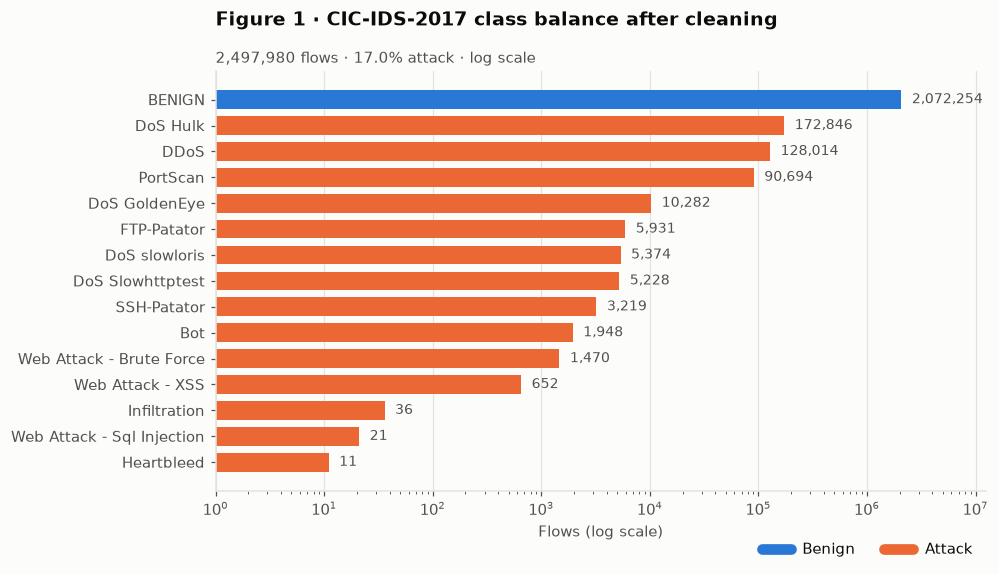

Imbalance ratio benign:attack = 4.9 : 1
Rarest family: Heartbleed (11 flows, 0.000440% of the corpus)


In [14]:
# ---------------------------------------------------------------------------------
# Figure 1 -- class balance. Log scale: the families span 11 to 2.07 million flows,
# which is five orders of magnitude and unreadable linearly.
# ---------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.2, 5.4))
order  = family.sort_values()
colors = [C_BENIGN if k == "BENIGN" else C_ATTACK for k in order.index]
bars   = ax.barh(range(len(order)), order.values, color=colors, height=0.72)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order.index)
ax.set_xscale("log")
ax.set_xlim(1, order.max() * 6)

for i, v in enumerate(order.values):            # direct value labels -- no colour-only reading
    ax.text(v * 1.25, i, f"{v:,}", va="center", fontsize=9, color=INK_SOFT)

ax.legend(handles=[Line2D([0],[0], color=C_BENIGN, lw=7, label="Benign"),
                   Line2D([0],[0], color=C_ATTACK, lw=7, label="Attack")],
          loc="lower right", bbox_to_anchor=(1.0, -0.19), ncol=2)   # clear of the shortest bars
finish(ax, "Figure 1 · CIC-IDS-2017 class balance after cleaning",
       f"{len(data):,} flows · {data['y'].mean():.1%} attack · log scale",
       xlabel="Flows (log scale)", xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

print(f"Imbalance ratio benign:attack = {data['y'].eq(0).sum()/data['y'].sum():.1f} : 1")
print(f"Rarest family: {family.index[-1]} ({family.iloc[-1]} flows, "
      f"{family.iloc[-1]/len(data):.6%} of the corpus)")

**Reading figure 1.** The corpus is dominated by benign traffic (82.96%), and the attack classes
themselves span five orders of magnitude — DoS Hulk contributes 172,846 flows while Heartbleed
contributes 11. Two consequences follow, and both shape the rest of the notebook:

* **Accuracy is a useless metric here.** Flagging nothing at all scores 83% accuracy. Every
  result in this notebook is therefore reported as precision, recall, F1 and PR-AUC.
* **A supervised classifier would essentially ignore the rare families** — 11 Heartbleed flows
  cannot outvote 2 million benign ones. The semi-supervised design sidesteps this entirely:
  because the model only learns *benign*, a rare attack is just as detectable as a common one,
  and section 14 shows that it is.

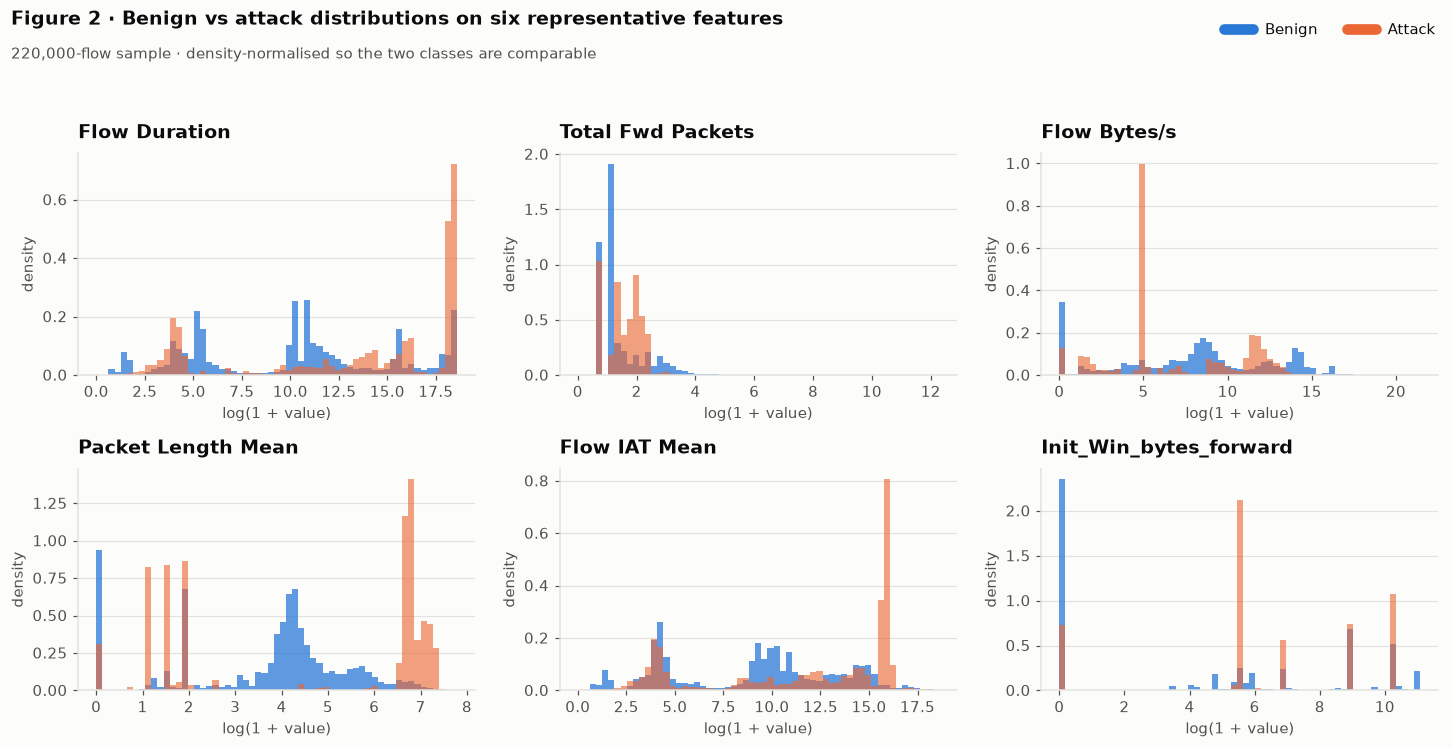

In [15]:
# ---------------------------------------------------------------------------------
# Figure 2 -- do attacks separate from benign on single features?
# Six features chosen to cover different behavioural axes: volume, timing, shape, flags.
# Log1p on the x-axis because all six are heavy-tailed counts/durations.
# ---------------------------------------------------------------------------------
PROBE_FEATURES = ["Flow Duration", "Total Fwd Packets", "Flow Bytes/s",
                  "Packet Length Mean", "Flow IAT Mean", "Init_Win_bytes_forward"]

samp = data.sample(min(220_000, len(data)), random_state=RANDOM_STATE)
b_s  = samp[samp.y == 0]
a_s  = samp[samp.y == 1]

fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.8))
for ax, feat in zip(axes.ravel(), PROBE_FEATURES):
    lo = np.log1p(np.clip(b_s[feat].to_numpy(), 0, None))
    la = np.log1p(np.clip(a_s[feat].to_numpy(), 0, None))
    bins = np.linspace(0, max(lo.max(), la.max()), 60)
    ax.hist(lo, bins=bins, color=C_BENIGN, alpha=0.75, density=True, label="Benign")
    ax.hist(la, bins=bins, color=C_ATTACK, alpha=0.62, density=True, label="Attack")
    finish(ax, feat, xlabel="log(1 + value)", ylabel="density")

fig.suptitle("Figure 2 · Benign vs attack distributions on six representative features",
             x=0.005, y=0.995, ha="left", va="top", fontsize=12.5, fontweight="semibold", color=INK)
fig.text(0.005, 0.945, f"{len(samp):,}-flow sample · density-normalised so the two classes are comparable",
         fontsize=9.5, color=INK_SOFT, va="top")
# Figure-level legend: every panel shares the same two series, and each panel is too busy to host it.
fig.legend(handles=[Line2D([0],[0], color=C_BENIGN, lw=7, label="Benign"),
                    Line2D([0],[0], color=C_ATTACK, lw=7, label="Attack")],
           loc="upper right", bbox_to_anchor=(0.995, 0.995), ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.915]); plt.show()

**Reading figure 2.** The two classes are visibly displaced on every panel, but never cleanly
separated — the distributions overlap heavily. That is the central finding of the EDA and it
justifies the whole modelling approach:

* Because the classes *do* differ, there is real signal for a density model to learn.
* Because no single feature separates them, a threshold rule on any one feature would be
  useless. `Flow Bytes/s` shows the attack mass shifted high (flooding) *and* a second lobe
  shifted low (slow-rate DoS such as slowloris), so even the direction of "anomalous" is not
  consistent within one feature.
* The separation must therefore be found **jointly, across many features at once** — which is
  precisely what a multivariate Gaussian does through its covariance matrix, and what a
  per-feature rule cannot do.

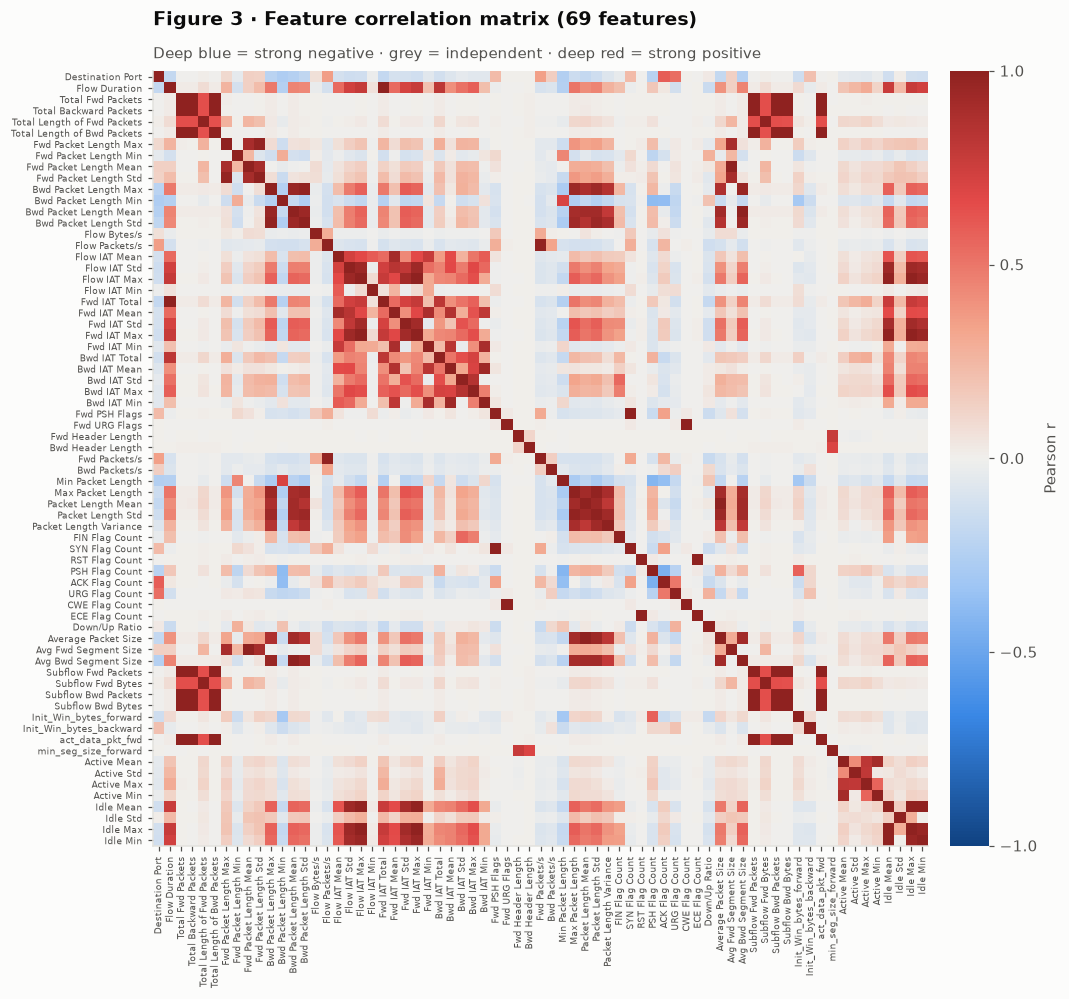

feature pairs            : 4,761
pairs with |r| > 0.95    : 44
pairs with |r| > 0.99    : 32

most redundant pairs:
Total Length of Fwd Packets  Subflow Fwd Bytes       1.0
Fwd PSH Flags                SYN Flag Count          1.0
Bwd Packet Length Mean       Avg Bwd Segment Size    1.0
Fwd URG Flags                CWE Flag Count          1.0
Total Backward Packets       Subflow Bwd Packets     1.0
Fwd Packet Length Mean       Avg Fwd Segment Size    1.0
RST Flag Count               ECE Flag Count          1.0
Total Fwd Packets            Subflow Fwd Packets     1.0


In [16]:
# ---------------------------------------------------------------------------------
# Figure 3 -- feature redundancy. Correlation is a polarity quantity (-1..+1),
# so this uses a diverging ramp with a neutral grey midpoint anchored at zero.
# ---------------------------------------------------------------------------------
corr = data[FEATURES].sample(min(300_000, len(data)), random_state=RANDOM_STATE).corr().fillna(0)

fig, ax = plt.subplots(figsize=(11.2, 9.2))
im = ax.imshow(corr.to_numpy(), cmap=DIV_BR, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=90, fontsize=6.2)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=6.2)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Pearson r", color=INK_SOFT); cb.outline.set_visible(False)
finish(ax, "Figure 3 · Feature correlation matrix (69 features)",
       "Deep blue = strong negative · grey = independent · deep red = strong positive",
       xgrid=False, ygrid=False)
plt.tight_layout(); plt.show()

tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(f"feature pairs            : {len(tri):,}")
print(f"pairs with |r| > 0.95    : {(tri.abs() > 0.95).sum():,}")
print(f"pairs with |r| > 0.99    : {(tri.abs() > 0.99).sum():,}")
print("\nmost redundant pairs:")
print(tri.abs().sort_values(ascending=False).head(8).to_string())

**Reading figure 3.** The red blocks along the diagonal are groups of features that measure the
same thing under different names — `Packet Length Std` against `Packet Length Variance` (one is
the square of the other), `Subflow Fwd Bytes` against `Total Length of Fwd Packets`,
`Avg Fwd Segment Size` against `Fwd Packet Length Mean`.

This is not a cosmetic problem. A Gaussian model inverts the covariance matrix Σ, and a pair of
features with |r| ≈ 1 makes Σ **singular** — the inversion either fails outright or produces
enormous, numerically meaningless values. Section 6 therefore prunes this redundancy before any
model is fitted.

## 6. Feature engineering

Three transformations, in order. Each one exists to repair a specific violation of the Gaussian
model's assumptions that was measured above.

**(a) Variance-stabilising transform.** Network features are heavy-tailed counts, byte totals and
durations — `Flow Duration` alone spans roughly 0 to 10⁸ µs. A Gaussian fitted to a raw
power-law feature is dominated by the extreme tail. A signed `log1p` compresses the tail while
preserving order and handling the legitimate negative values CIC-IDS-2017 contains (for example
`Init_Win_bytes_forward = -1` meaning "no window advertised").

**(b) Collinearity prune.** Greedily keep a feature only if its |r| against every already-kept
feature is ≤ 0.95. This is what makes Σ invertible, per figure 3.

**(c) Gaussianisation.** Even after `log1p`, several features stay skewed or bimodal. A quantile
transform maps each feature's empirical distribution onto a standard normal, in the spirit of
Parisi's Chapter 5 guidance to transform features toward normality before fitting the density.

This works on the *continuous* features and provably cannot work on some of the others, which is
worth stating plainly rather than glossing: a quantile transform can only spread values that are
distinct. A feature that is a single repeated value for 99% of benign flows has almost no
quantiles to map, so it stays degenerate no matter what transform is applied. The diagnostic
below measures exactly how many features are in that state — and the residual non-normality it
reports is itself part of the reason a single Gaussian underfits in section 9.

> **Every one of these is fitted on the benign training split only** and then applied to
> validation and test. Fitting a scaler or a correlation matrix on all the data would leak
> attack information into the "attack-blind" model and inflate the results.

In [17]:
X_raw = data[FEATURES].to_numpy(dtype=np.float32)
y     = data["y"].to_numpy()
labels_all = data["Label"].to_numpy()

# (a) signed log1p -- compresses heavy tails, keeps sign, defined at 0 and for negatives
X_log = (np.sign(X_raw) * np.log1p(np.abs(X_raw, dtype=np.float64))).astype(np.float32)

def mean_abs_skew(M):
    """|skew| per column, measured on a sample so memory stays flat on millions of rows."""
    s = M[RNG.choice(len(M), min(200_000, len(M)), replace=False)].astype(np.float64)
    c = s - s.mean(0)
    sd = c.std(0); sd[sd == 0] = 1.0
    return np.abs((c ** 3).mean(0) / sd ** 3)

sk_raw, sk_log = mean_abs_skew(X_raw), mean_abs_skew(X_log)
print("(a) signed log1p")
print(f"    mean |skew| : {sk_raw.mean():10.2f}  ->  {sk_log.mean():7.2f}")
print(f"    max  |skew| : {sk_raw.max():10.2f}  ->  {sk_log.max():7.2f}")
print(f"    features with |skew| > 10 : {(sk_raw > 10).sum()}  ->  {(sk_log > 10).sum()}")

(a) signed log1p
    mean |skew| :      45.25  ->     7.31
    max  |skew| :     429.20  ->   149.06
    features with |skew| > 10 : 25  ->  5


### What the tie diagnostic shows

The transform does its job on the continuous features — their mean |skew| lands near 0.8, which
is close to normal. A handful of flag counters cannot be fixed: `Fwd URG Flags` and
`RST Flag Count` are **completely constant among benign traffic**.

That is worth dwelling on, because it is not a defect — it is a signal. These features were not
removed by the corpus-wide constant prune in section 4 precisely because they *do* vary: they
vary in **attack** traffic. A RST-flag count that is always zero in normal traffic and non-zero
during a scan is close to an ideal anomaly indicator.

They were deliberately kept. Pruning them was tested and did not improve validation PR-AUC, so
retaining them costs nothing and keeps genuine signal available to the model. The consequence to
be aware of is that these directions have near-zero benign variance, which is what the ridge
term in section 8 exists to stabilise.

## 7. The semi-supervised split

The split is what makes this anomaly detection rather than classification:

| Split | Benign | Attack | Purpose |
|---|---|---|---|
| **Train** | 60% | **none** | Fit the density model. Sees only normal traffic. |
| **Validation** | 20% | 50% | Choose the threshold ε and the mixture size k. |
| **Test** | 20% | 50% | Reported once, at the end. Touched by nothing else. |

Attacks are split **stratified by family**, so every family — including the 11 Heartbleed flows —
is represented in both validation and test rather than landing entirely in one of them.

> **A caveat that must be carried through every later result.** Because training consumes 60% of
> the benign flows but *no* attacks, attacks are concentrated in what remains: the validation and
> test splits run at roughly **34% attack prevalence, not the corpus's 17%**. Recall, ROC-AUC and
> FPR are unaffected by this — they are computed within a single class. **Precision and PR-AUC
> are not.** Both depend on the base rate, so the precision figures reported below are optimistic
> relative to what the same thresholds would yield on live traffic at 17% prevalence, and more
> optimistic still against a real network where attack flows are a fraction of a percent. The
> relative comparison between models remains valid, since all three are scored on the identical
> split.

In [18]:
benign_idx = np.flatnonzero(y == 0)
attack_idx = np.flatnonzero(y == 1)

b_train, b_rest = train_test_split(benign_idx, test_size=0.40, random_state=RANDOM_STATE)
b_val,   b_test = train_test_split(b_rest,     test_size=0.50, random_state=RANDOM_STATE)
a_val,   a_test = train_test_split(attack_idx, test_size=0.50, random_state=RANDOM_STATE,
                                   stratify=labels_all[attack_idx])

val_idx  = np.concatenate([b_val,  a_val])
test_idx = np.concatenate([b_test, a_test])

split_table = pd.DataFrame({
    "benign": [len(b_train), len(b_val), len(b_test)],
    "attack": [0, len(a_val), len(a_test)],
    "total":  [len(b_train), len(val_idx), len(test_idx)],
    "attack %": [0.0, y[val_idx].mean()*100, y[test_idx].mean()*100],
}, index=["train (benign only)", "validation", "test"])
print(split_table.to_string(formatters={"benign": "{:,}".format, "attack": "{:,}".format,
                                        "total": "{:,}".format, "attack %": "{:.2f}%".format}))

assert y[b_train].sum() == 0, "an attack leaked into the benign-only training split"
assert len(set(b_train) & set(b_test)) == 0, "train/test overlap"
print("\nleakage checks passed: training split contains zero attacks, no train/test overlap")

                       benign  attack     total attack %
train (benign only) 1,243,352       0 1,243,352    0.00%
validation            414,451 212,863   627,314   33.93%
test                  414,451 212,863   627,314   33.93%

leakage checks passed: training split contains zero attacks, no train/test overlap


In [19]:
# (b) collinearity prune -- correlation measured on TRAIN BENIGN ONLY
corr_train = np.nan_to_num(np.corrcoef(X_log[b_train].T))
keep_idx = []
for i in range(len(FEATURES)):
    if all(abs(corr_train[i, j]) <= CORR_CUTOFF for j in keep_idx):
        keep_idx.append(i)
KEPT = [FEATURES[i] for i in keep_idx]
dropped = [f for f in FEATURES if f not in KEPT]

print(f"(b) collinearity prune at |r| > {CORR_CUTOFF}")
print(f"    {len(FEATURES)} features -> {len(KEPT)} kept, {len(dropped)} dropped")
print(f"    dropped: {', '.join(dropped[:12])}{' ...' if len(dropped) > 12 else ''}")

# (c) Gaussianisation -- fitted on train benign, applied everywhere
qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000,
                         subsample=200_000, random_state=RANDOM_STATE)
qt.fit(X_log[b_train][:, keep_idx])
Z = np.clip(qt.transform(X_log[:, keep_idx]), -6, 6).astype(np.float64)  # clip: guard ±inf at the quantile edges

print(f"\n(c) quantile -> normal on {len(KEPT)} features")
print(f"    design matrix Z {Z.shape}  |  train-benign mean {Z[b_train].mean():+.4f}, sd {Z[b_train].std():.4f}")
print(f"    mean |skew| after Gaussianisation: {pd.DataFrame(Z[b_train]).skew().abs().mean():.3f}")

# How much of each feature is a single repeated value, measured on benign training data?
_tr = X_log[b_train][:, keep_idx]
mode_share = np.array([pd.Series(_tr[:, j]).value_counts(normalize=True).iloc[0]
                       for j in range(_tr.shape[1])])
_c = Z[b_train] - Z[b_train].mean(0); _sd = _c.std(0); _sd[_sd == 0] = 1.0
post_skew = np.abs((_c ** 3).mean(0) / _sd ** 3)
continuous = mode_share <= 0.90
del _tr, _c, _sd

print(f"\n    tie diagnostic (share of each feature that is one repeated value, benign train):")
print(f"      near-degenerate (>90% one value) : {(~continuous).sum()} features")
print(f"      genuinely continuous             : {continuous.sum()} features")
print(f"    mean |skew| after transform  ->  continuous {post_skew[continuous].mean():.3f}"
      f"  |  near-degenerate {post_skew[~continuous].mean():.1f}  |  overall {post_skew.mean():.2f}")
print("\n    worst offenders (constant or near-constant among benign traffic):")
for j in np.argsort(-mode_share)[:4]:
    print(f"      {KEPT[j]:26s} {mode_share[j]:6.1%} one value   post-transform |skew| {post_skew[j]:8.1f}")

cond = np.linalg.cond(np.cov(Z[b_train], rowvar=False))
print(f"\n    condition number of Sigma : {cond:,.0f}  ({'invertible' if cond < 1e12 else 'SINGULAR'})")

(b) collinearity prune at |r| > 0.95
    69 features -> 40 kept, 29 dropped
    dropped: Fwd Packet Length Max, Bwd Packet Length Max, Bwd Packet Length Mean, Flow Packets/s, Flow IAT Mean, Flow IAT Max, Fwd IAT Mean, Fwd IAT Max, Bwd IAT Mean, Bwd IAT Max, Fwd Packets/s, Min Packet Length ...

(c) quantile -> normal on 40 features
    design matrix Z (2497980, 40)  |  train-benign mean -1.9321, sd 2.9762
    mean |skew| after Gaussianisation: 6.836

    tie diagnostic (share of each feature that is one repeated value, benign train):
      near-degenerate (>90% one value) : 5 features
      genuinely continuous             : 35 features
    mean |skew| after transform  ->  continuous 0.849  |  near-degenerate 48.7  |  overall 6.84

    worst offenders (constant or near-constant among benign traffic):
      Fwd URG Flags              100.0% one value   post-transform |skew|    172.0
      RST Flag Count             100.0% one value   post-transform |skew|     55.6
      FIN Flag Count  

## 8. The multivariate Gaussian anomaly detector

This is the Chapter 5 method implemented from first principles rather than called from a library,
because the mechanics are the point of the lab.

Fit the benign training data with a single multivariate normal, estimating

$$\mu = \frac{1}{m}\sum_{i=1}^{m} x^{(i)}, \qquad
  \Sigma = \frac{1}{m-1}\sum_{i=1}^{m} (x^{(i)}-\mu)(x^{(i)}-\mu)^{\top}$$

and score any flow by its log-density

$$\log p(x) = -\tfrac{1}{2}\Big[d\log 2\pi + \log|\Sigma| + (x-\mu)^{\top}\Sigma^{-1}(x-\mu)\Big].$$

A flow is flagged as an intrusion when $\log p(x) < \log\varepsilon$ — it sits in a region the
benign model considers implausible.

**Three implementation details that matter:**

1. **Work in log space.** `p(x)` for d = 40 underflows float64 to exactly 0 for any realistic
   flow, so every comparison would be `0 < 0`. The log-density stays in a representable range.
2. **Use a Cholesky factorisation, not `inv(Σ)`.** Σ = LLᵀ gives the Mahalanobis term by
   triangular solve and `log|Σ| = 2·Σ log(diag L)` for free. Explicitly inverting a 40×40
   covariance matrix is both slower and numerically worse.
3. **Ridge-regularise Σ.** Adding λ·tr(Σ)/d · I guarantees positive-definiteness even if the
   prune in section 6 left a near-degenerate direction. λ = 1e-6 is small enough not to distort
   the fit.

Scoring is a single matrix operation, which is why this model is cheap enough to run inline on
live traffic — the point section 17 returns to.

In [20]:
@dataclass
class GaussianAnomalyDetector:
    """Multivariate Gaussian density model (Parisi 2019, ch. 5), Cholesky-based.

    Fitted on benign traffic only; `score` returns log p(x), lower = more anomalous.
    """
    ridge: float = 1e-6

    def fit(self, X):
        self.mu_ = X.mean(axis=0)
        S = np.cov(X, rowvar=False)
        self.d_ = S.shape[0]
        S = S + np.eye(self.d_) * self.ridge * np.trace(S) / self.d_   # (3) ridge
        self.chol_ = cho_factor(S, lower=True)                          # (2) Cholesky
        self.logdet_ = 2.0 * np.sum(np.log(np.diag(self.chol_[0])))
        self._const = self.d_ * np.log(2.0 * np.pi) + self.logdet_
        return self

    def score(self, X, chunk=200_000):
        """log p(x), computed in chunks so memory stays flat on millions of rows."""
        out = np.empty(len(X), dtype=np.float64)
        for s in range(0, len(X), chunk):
            D = X[s:s + chunk] - self.mu_
            maha = np.einsum("ij,ij->i", D, cho_solve(self.chol_, D.T).T)
            out[s:s + chunk] = -0.5 * (self._const + maha)              # (1) log space
        return out

t0 = time.time()
gauss = GaussianAnomalyDetector().fit(Z[b_train])
score_gauss = gauss.score(Z)
print(f"fitted on {len(b_train):,} benign flows and scored {len(Z):,} flows in {time.time()-t0:.1f}s")
print(f"   dimensions d      : {gauss.d_}")
print(f"   log|Sigma|        : {gauss.logdet_:,.2f}")
print(f"   mean log p(x) benign : {score_gauss[y==0].mean():10.2f}")
print(f"   mean log p(x) attack : {score_gauss[y==1].mean():10.2f}")
print(f"   separation           : {score_gauss[y==0].mean() - score_gauss[y==1].mean():10.2f} nats")

fitted on 1,243,352 benign flows and scored 2,497,980 flows in 0.6s
   dimensions d      : 40
   log|Sigma|        : -24.39
   mean log p(x) benign :     -44.64
   mean log p(x) attack :     -88.14
   separation           :      43.49 nats


## 9. Choosing the threshold ε

ε is the only supervised quantity in the model, and it is chosen on the **validation split**,
never on test.

The objective is **F1**, not accuracy. A detector that flags nothing scores 83% accuracy on the
full corpus and 66% on this evaluation split — in both cases far above what it deserves, which is
why accuracy cannot distinguish a working IDS from a switched-off one. F1 balances the two errors
an analyst actually cares about: missed intrusions (recall) and false alarms that burn triage
time (precision).

The sweep evaluates 600 candidate thresholds drawn from the quantiles of the validation scores,
which concentrates the search where the decision boundary actually lies.

In [21]:
def sweep_threshold(scores, y_true, idx, n=600, qmax=0.60):
    """Evaluate precision/recall/F1 across candidate epsilons; return the sweep and the argmax-F1."""
    eps_grid = np.quantile(scores[idx], np.linspace(1e-4, qmax, n))
    rows = []
    for e in eps_grid:
        p, r, f, _ = precision_recall_fscore_support(
            y_true[idx], (scores[idx] < e).astype(int), average="binary", zero_division=0)
        rows.append((e, p, r, f))
    sweep = pd.DataFrame(rows, columns=["eps", "precision", "recall", "f1"])
    return sweep, sweep.loc[sweep.f1.idxmax()]

sweep_g, best_g = sweep_threshold(score_gauss, y, val_idx)
EPS_GAUSS = best_g.eps
print(f"best epsilon (log p) : {EPS_GAUSS:.4f}")
print(f"validation           : precision {best_g.precision:.4f} | recall {best_g.recall:.4f} | F1 {best_g.f1:.4f}")

best epsilon (log p) : -50.7824
validation           : precision 0.7028 | recall 0.9606 | F1 0.8117


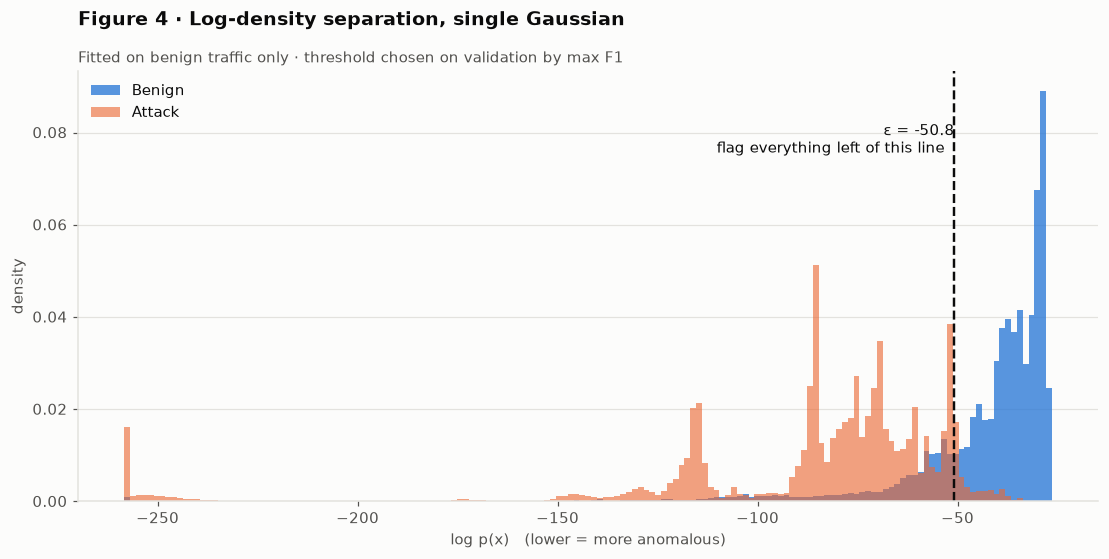

In [22]:
# ---------------------------------------------------------------------------------
# Figure 4 -- where the two classes sit on the log-density axis, and where eps lands.
# ---------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.2, 5.2))
lo = np.percentile(score_gauss, 0.5)
bins = np.linspace(lo, score_gauss.max(), 160)
ax.hist(np.clip(score_gauss[y == 0], lo, None), bins=bins, color=C_BENIGN, alpha=0.78,
        density=True, label="Benign")
ax.hist(np.clip(score_gauss[y == 1], lo, None), bins=bins, color=C_ATTACK, alpha=0.62,
        density=True, label="Attack")
ax.axvline(EPS_GAUSS, color=INK, lw=1.6, ls="--")
# right-aligned: epsilon sits near the right edge, so a left-aligned note runs off-plot
ax.annotate(f"ε = {EPS_GAUSS:,.1f}\nflag everything left of this line  ",
            xy=(EPS_GAUSS, ax.get_ylim()[1]*0.88), fontsize=9.5, color=INK,
            ha="right", va="top")
ax.legend(loc="upper left")
finish(ax, "Figure 4 · Log-density separation, single Gaussian",
       "Fitted on benign traffic only · threshold chosen on validation by max F1",
       xlabel="log p(x)   (lower = more anomalous)", ylabel="density")
plt.tight_layout(); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


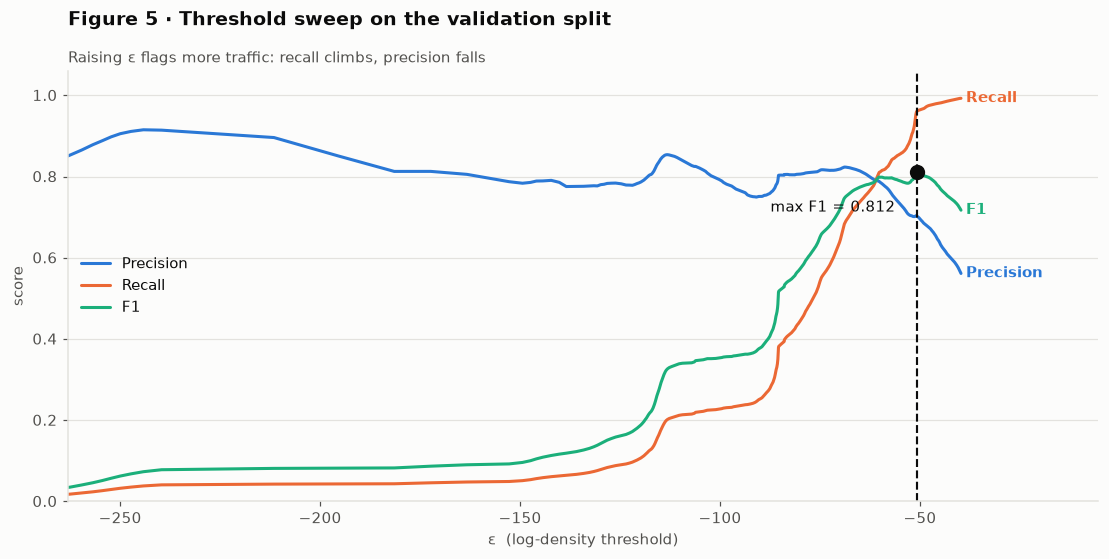

In [23]:
# ---------------------------------------------------------------------------------
# Figure 5 -- the precision/recall trade-off across epsilon.
# Three series => categorical slots 1,2,3 in fixed order, each directly labelled
# (slot 3 sits under 3:1 contrast on white, so a direct label is mandatory, not optional).
# ---------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.2, 5.2))
for col, c, lab in zip(["precision", "recall", "f1"], CATEGORICAL, ["Precision", "Recall", "F1"]):
    ax.plot(sweep_g.eps, sweep_g[col], color=c, label=lab)
    ax.text(sweep_g.eps.iloc[-1], sweep_g[col].iloc[-1], f" {lab}", color=c,
            fontsize=9.5, va="center", fontweight="semibold")

ax.axvline(EPS_GAUSS, color=INK, lw=1.4, ls="--")
ax.plot([EPS_GAUSS], [best_g.f1], "o", ms=9, color=INK, zorder=5)
ax.annotate(f"max F1 = {best_g.f1:.3f}", xy=(EPS_GAUSS, best_g.f1),
            xytext=(-14, -26), textcoords="offset points", fontsize=9.5,
            color=INK, ha="right")   # left of the line: the direct labels own the right edge
# The epsilon grid spans a huge range in which nothing happens; show only the active band.
active = sweep_g[sweep_g.f1 >= 0.05]
x0 = active.eps.min() if len(active) else sweep_g.eps.min()
x1 = sweep_g.eps.max()
ax.set_xlim(x0 - (x1 - x0) * 0.04, x1 + (x1 - x0) * 0.16)
ax.set_ylim(0, 1.06)
ax.legend(loc="center left", ncol=1)   # the low-left corner is occupied by the curves
finish(ax, "Figure 5 · Threshold sweep on the validation split",
       "Raising ε flags more traffic: recall climbs, precision falls",
       xlabel="ε  (log-density threshold)", ylabel="score")
plt.tight_layout(); plt.show()

**Reading figures 4 and 5.** Figure 4 shows the mechanism working: the attack mass sits left of
the benign mass on the log-density axis, exactly as the model intends. But the overlap in the
middle is substantial, and that overlap *is* the error budget — every flow in it will be either a
false alarm or a miss, whatever ε is chosen.

Figure 5 quantifies the consequence. The curves cross in a narrow band, and the F1 peak is
shallow: there is no ε that gives both high precision and high recall. The single Gaussian is
forcing a genuinely bad trade-off, which is the specific problem section 10 sets out to fix.

## 10. From one Gaussian to a mixture

Figure 4 exposes the flaw in the single-Gaussian model. It assumes benign traffic forms **one
elliptical cloud** around a single mean. Real benign traffic does not: a DNS lookup, a bulk HTTPS
download and an idle keep-alive are three completely different behaviours. Forcing one ellipse
over all of them produces a mean that describes none of them, and an ellipse wide enough to
swallow attacks that sit between the real clusters.

A **Gaussian Mixture Model** fixes exactly this. It models benign traffic as k Gaussian
components fitted by expectation-maximisation,

$$p(x) = \sum_{j=1}^{k}\pi_j\,\mathcal{N}(x\mid\mu_j,\Sigma_j),$$

and scores a flow by the same log-density rule. It remains a Gaussian density model in the
Chapter 5 sense, and it is simultaneously a **soft clustering** of normal behaviour — each
component is a mode of legitimate traffic discovered without labels.

**k is selected on validation by PR-AUC**, which is threshold-independent and the right summary
statistic under heavy class imbalance (unlike ROC-AUC, it is not flattered by the large benign
majority). Note that **k = 1 is mathematically the single Gaussian of section 8**, so the sweep
below measures precisely what the mixture buys.

One honest caveat on reading the sweep: the jump from k = 1 to k ≈ 6 is large and robust, but the
curve is **flat above that**, and because each mixture is fitted by EM on a random subsample the
exact argmax moves between runs. The defensible claim is "several components beat one", not
"twelve is the uniquely correct number".

In [24]:
def score_in_chunks(model, X, chunk=200_000):
    return np.concatenate([model.score_samples(X[s:s+chunk]) for s in range(0, len(X), chunk)])

# Dedicated generator so this subsample does not depend on how much earlier cells consumed RNG.
fit_rows = np.random.default_rng(RANDOM_STATE).choice(
    b_train, min(GMM_FIT_ROWS, len(b_train)), replace=False)
print(f"fitting each GMM on {len(fit_rows):,} benign training flows\n")
print(f"{'k':>3s} {'val PR-AUC':>11s} {'val ROC-AUC':>12s} {'val F1':>8s} {'BIC':>14s} {'fit s':>7s}")
print("-" * 62)

gmm_rows, gmm_models, gmm_scores = [], {}, {}
for k in GMM_K_GRID:
    t0 = time.time()
    gm = GaussianMixture(n_components=k, covariance_type="full", reg_covar=1e-4,
                         random_state=RANDOM_STATE, max_iter=200, n_init=1).fit(Z[fit_rows])
    s = score_in_chunks(gm, Z)
    pr  = average_precision_score(y[val_idx], -s[val_idx])
    roc = roc_auc_score(y[val_idx], -s[val_idx])
    _, best_k = sweep_threshold(s, y, val_idx, n=200)
    bic = gm.bic(Z[fit_rows])
    dt = time.time() - t0
    gmm_rows.append({"k": k, "val_pr_auc": pr, "val_roc_auc": roc, "val_f1": best_k.f1,
                     "eps": best_k.eps, "bic": bic})
    gmm_models[k], gmm_scores[k] = gm, s
    print(f"{k:>3d} {pr:>11.4f} {roc:>12.4f} {best_k.f1:>8.4f} {bic:>14,.0f} {dt:>7.1f}")

gmm_df = pd.DataFrame(gmm_rows)
BEST_K = int(gmm_df.loc[gmm_df.val_pr_auc.idxmax(), "k"])
EPS_GMM = float(gmm_df.loc[gmm_df.val_pr_auc.idxmax(), "eps"])
score_gmm = gmm_scores[BEST_K]
print(f"\nselected k = {BEST_K} by validation PR-AUC, with epsilon = {EPS_GMM:.4f}")
print(f"PR-AUC lift over the single Gaussian (k=1): "
      f"{gmm_df.val_pr_auc.max() - gmm_df.loc[gmm_df.k==1,'val_pr_auc'].iloc[0]:+.4f}")

fitting each GMM on 300,000 benign training flows

  k  val PR-AUC  val ROC-AUC   val F1            BIC   fit s
--------------------------------------------------------------
  1      0.7856       0.9209   0.8118     26,781,593     5.1
  2      0.8129       0.9158   0.8078     17,633,974     6.2
  4      0.8686       0.9474   0.8506     -6,936,070     8.7
  6      0.8996       0.9585   0.8735    -13,561,513     9.2
  8      0.9170       0.9600   0.8629    -19,464,780    10.0
 10      0.9293       0.9654   0.8678    -19,746,065    10.9
 12      0.9138       0.9641   0.8761    -27,793,832    17.7
 16      0.9198       0.9579   0.8829    -31,696,365    18.6
 20      0.8741       0.9276   0.8147    -35,914,686    23.6

selected k = 10 by validation PR-AUC, with epsilon = -1.9237
PR-AUC lift over the single Gaussian (k=1): +0.1437


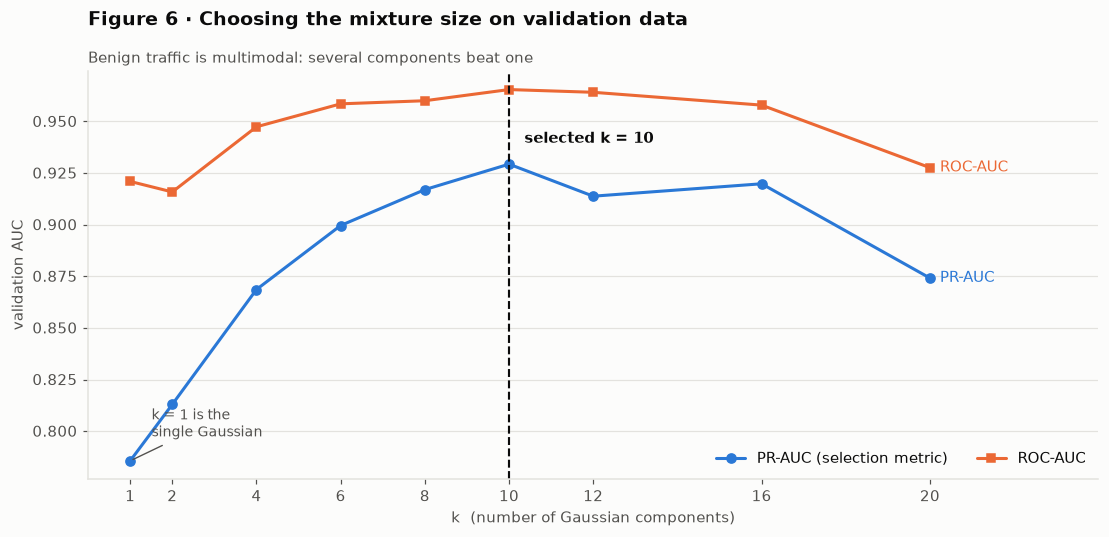

In [25]:
# ---------------------------------------------------------------------------------
# Figure 6 -- model selection. Two series on one axis (both are AUCs in 0..1),
# so they share a scale legitimately; k=1 is marked as the section-8 baseline.
# ---------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.2, 5.0))
ax.plot(gmm_df.k, gmm_df.val_pr_auc,  color=C_BENIGN, marker="o", ms=6, label="PR-AUC (selection metric)")
ax.plot(gmm_df.k, gmm_df.val_roc_auc, color=C_ATTACK, marker="s", ms=5.5, label="ROC-AUC")
ax.text(gmm_df.k.iloc[-1], gmm_df.val_pr_auc.iloc[-1], "  PR-AUC", color=C_BENIGN, fontsize=9.5, va="center")
ax.text(gmm_df.k.iloc[-1], gmm_df.val_roc_auc.iloc[-1], "  ROC-AUC", color=C_ATTACK, fontsize=9.5, va="center")

ax.axvline(BEST_K, color=INK, lw=1.4, ls="--")
ax.annotate(f"selected k = {BEST_K}", xy=(BEST_K, gmm_df.val_pr_auc.max()),
            xytext=(10, 14), textcoords="offset points", fontsize=9.5,
            color=INK, fontweight="semibold")
ax.annotate("k = 1 is the\nsingle Gaussian", xy=(1, gmm_df.loc[gmm_df.k==1,"val_pr_auc"].iloc[0]),
            xytext=(14, 16), textcoords="offset points", fontsize=9, color=INK_SOFT,
            arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=0.9))
ax.set_xticks(list(GMM_K_GRID)); ax.set_xlim(0, max(GMM_K_GRID) + 4)
ax.legend(loc="lower right", ncol=2)
finish(ax, "Figure 6 · Choosing the mixture size on validation data",
       "Benign traffic is multimodal: several components beat one",
       xlabel="k  (number of Gaussian components)", ylabel="validation AUC")
plt.tight_layout(); plt.show()

## 11. Benchmark: Isolation Forest

A second, structurally different unsupervised detector, trained on the same benign-only split.
Isolation Forest makes no distributional assumption at all — it isolates points with random axis
splits and calls a point anomalous when it separates in few splits.

Including it answers the obvious challenge to section 10: *is the mixture actually good, or does
any unsupervised method score this well on CIC-IDS-2017?* Without a contrasting baseline the
GMM's numbers have nothing to be measured against.

In [26]:
t0 = time.time()
iso = IsolationForest(n_estimators=200, max_samples=256, contamination="auto",
                      random_state=RANDOM_STATE, n_jobs=-1).fit(Z[fit_rows])
score_iso = score_in_chunks(iso, Z)
sweep_i, best_i = sweep_threshold(score_iso, y, val_idx)
EPS_ISO = best_i.eps
print(f"trained and scored in {time.time()-t0:.1f}s")
print(f"validation: precision {best_i.precision:.4f} | recall {best_i.recall:.4f} | F1 {best_i.f1:.4f}")
print(f"validation PR-AUC {average_precision_score(y[val_idx], -score_iso[val_idx]):.4f}")

trained and scored in 22.9s
validation: precision 0.5689 | recall 0.9723 | F1 0.7178
validation PR-AUC 0.6283


## 12. Test-set evaluation

The held-out test split is scored once, here, with thresholds and k fixed from validation.
Nothing below this line feeds back into any modelling decision.

In [27]:
MODELS = {
    "Single Gaussian":       (score_gauss, EPS_GAUSS, C_BENIGN),
    f"GMM (k={BEST_K})":     (score_gmm,   EPS_GMM,   C_ATTACK),
    "Isolation Forest":      (score_iso,   EPS_ISO,   C_THIRD),
}

def evaluate(scores, eps, idx):
    yhat = (scores[idx] < eps).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y[idx], yhat, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y[idx], yhat).ravel()
    return {
        "precision": p, "recall": r, "f1": f,
        "roc_auc": roc_auc_score(y[idx], -scores[idx]),
        "pr_auc":  average_precision_score(y[idx], -scores[idx]),
        "fpr": fp / (fp + tn), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

results = pd.DataFrame({name: evaluate(s, e, test_idx) for name, (s, e, _) in MODELS.items()}).T
print("TEST SPLIT  ({:,} flows, {:.2%} attack)\n".format(len(test_idx), y[test_idx].mean()))
print(results[["precision", "recall", "f1", "roc_auc", "pr_auc", "fpr"]]
      .to_string(float_format=lambda v: f"{v:.4f}"))
print("\nconfusion counts")
print(results[["TP", "FP", "FN", "TN"]].astype(int).to_string(formatters={c: "{:,}".format for c in ["TP","FP","FN","TN"]}))

BEST_NAME = results.f1.idxmax()
best_scores, best_eps, _ = MODELS[BEST_NAME]
print(f"\nbest model by test F1: {BEST_NAME}")

TEST SPLIT  (627,314 flows, 33.93% attack)

                  precision  recall     f1  roc_auc  pr_auc    fpr
Single Gaussian      0.7028  0.9607 0.8117   0.9211  0.7869 0.2087
GMM (k=10)           0.8214  0.9194 0.8677   0.9655  0.9296 0.1026
Isolation Forest     0.5689  0.9721 0.7177   0.8477  0.6290 0.3783

confusion counts
                      TP      FP     FN      TN
Single Gaussian  204,491  86,477  8,372 327,974
GMM (k=10)       195,705  42,543 17,158 371,908
Isolation Forest 206,914 156,805  5,949 257,646

best model by test F1: GMM (k=10)


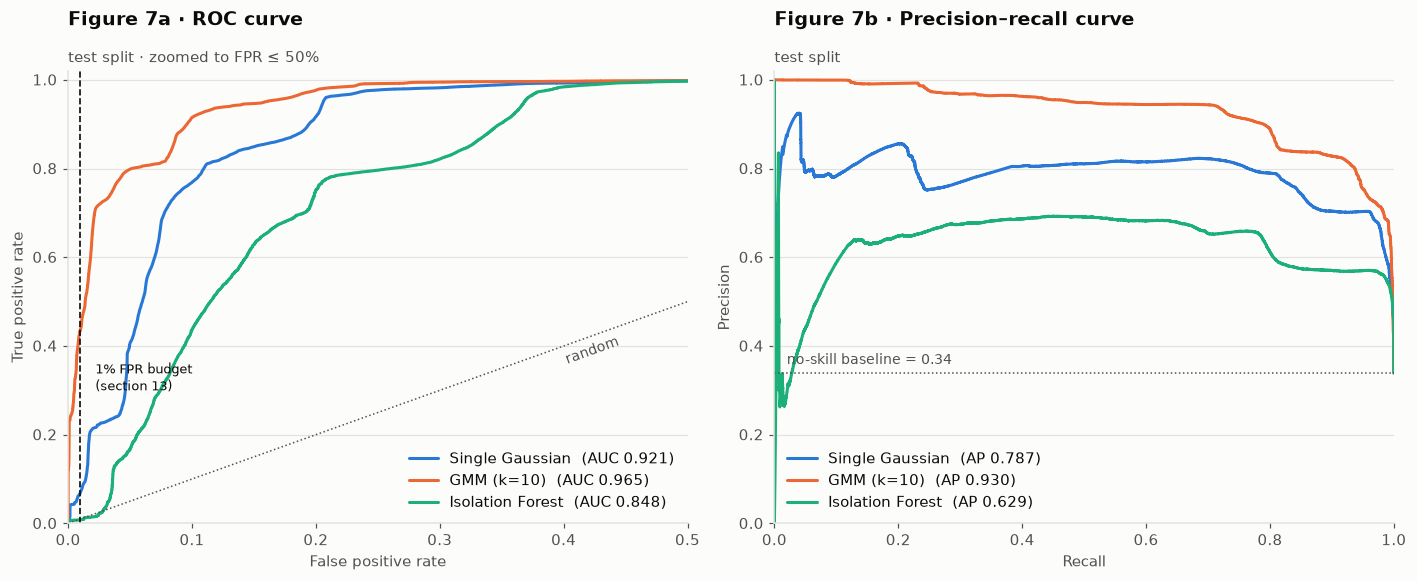

In [28]:
# ---------------------------------------------------------------------------------
# Figure 7 -- ROC and precision-recall, all three models. Three line series =>
# categorical slots 1,2,3 in fixed order, legend plus direct labels.
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))

for name, (s, e, c) in MODELS.items():
    fpr, tpr, _ = roc_curve(y[test_idx], -s[test_idx])
    axes[0].plot(fpr, tpr, color=c, label=f"{name}  (AUC {results.loc[name,'roc_auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y[test_idx], -s[test_idx])
    axes[1].plot(rec, prec, color=c, label=f"{name}  (AP {results.loc[name,'pr_auc']:.3f})")

ROC_XMAX = 0.5          # the full 0-1 range wastes half the panel; all separation is on the left
axes[0].plot([0, 1], [0, 1], color=INK_SOFT, lw=1.0, ls=":")
axes[0].text(0.40, 0.36, "random", color=INK_SOFT, fontsize=9, rotation=20)
axes[0].axvline(TARGET_FPR, color=INK, lw=1.1, ls="--")
axes[0].text(TARGET_FPR + 0.012, 0.30, f"{TARGET_FPR:.0%} FPR budget\n(section 13)", fontsize=8.8, color=INK)
axes[0].set_xlim(0, ROC_XMAX); axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="lower right")
finish(axes[0], "Figure 7a · ROC curve", f"test split · zoomed to FPR ≤ {ROC_XMAX:.0%}",
       xlabel="False positive rate", ylabel="True positive rate")

base = y[test_idx].mean()
axes[1].axhline(base, color=INK_SOFT, lw=1.0, ls=":")
axes[1].text(0.02, base + 0.02, f"no-skill baseline = {base:.2f}", fontsize=9, color=INK_SOFT)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower left")
finish(axes[1], "Figure 7b · Precision–recall curve", "test split", xlabel="Recall", ylabel="Precision")
plt.tight_layout(); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


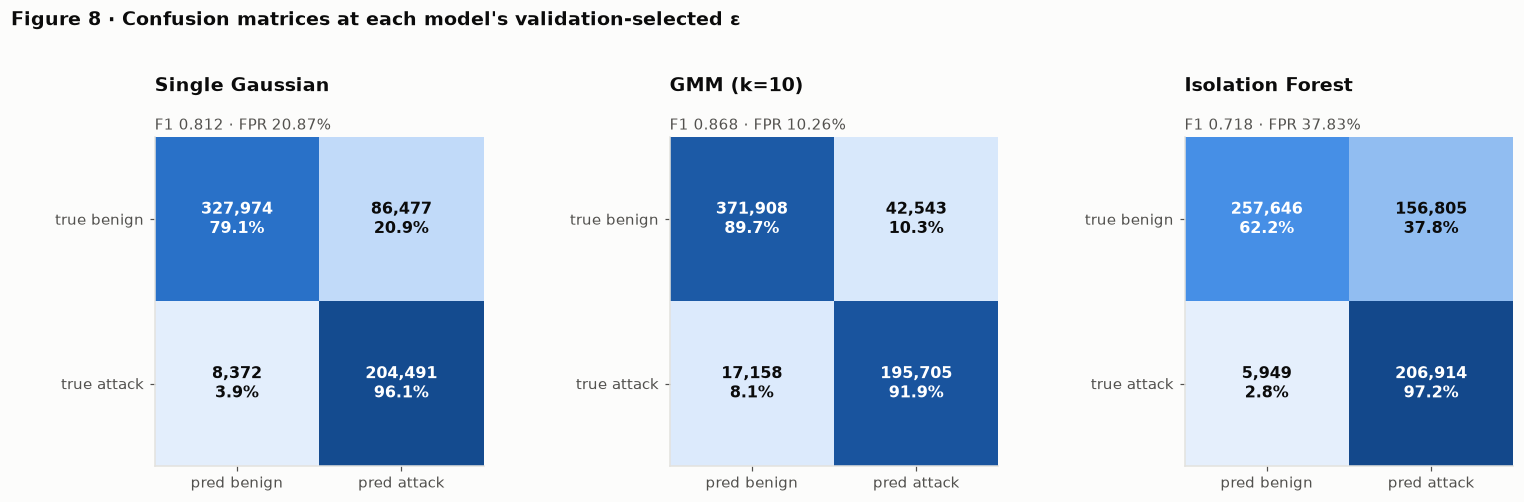

              precision    recall  f1-score   support

      benign     0.9559    0.8974    0.9257    414451
      attack     0.8214    0.9194    0.8677    212863

    accuracy                         0.9048    627314
   macro avg     0.8887    0.9084    0.8967    627314
weighted avg     0.9103    0.9048    0.9060    627314



In [29]:
# ---------------------------------------------------------------------------------
# Figure 8 -- confusion matrices. Counts are magnitude => single-hue sequential ramp,
# row-normalised so the benign and attack rows are comparable despite 5:1 imbalance.
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.5))
for ax, (name, (s, e, _)) in zip(axes, MODELS.items()):
    cm = confusion_matrix(y[test_idx], (s[test_idx] < e).astype(int))
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cmn, cmap=SEQ_BLUE, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}\n{cmn[i,j]:.1%}", ha="center", va="center",
                    fontsize=10.5, fontweight="semibold",
                    color="#ffffff" if cmn[i, j] > 0.55 else INK)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred benign", "pred attack"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true benign", "true attack"])
    ax.grid(False)
    finish(ax, name, f"F1 {results.loc[name,'f1']:.3f} · FPR {results.loc[name,'fpr']:.2%}",
           xgrid=False, ygrid=False)
fig.suptitle("Figure 8 · Confusion matrices at each model's validation-selected ε",
             x=0.005, ha="left", fontsize=12.5, fontweight="semibold", color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

print(classification_report(y[test_idx], (best_scores[test_idx] < best_eps).astype(int),
                            target_names=["benign", "attack"], digits=4))

**Reading figures 7 and 8.** Three findings:

1. **The mixture beats the single Gaussian decisively**, and the gain is largest exactly where it
   matters. On the left of figure 7a — the low-false-positive region, the only part of the ROC
   curve a real SOC ever operates in — the single Gaussian is close to worthless, while the
   mixture retains substantial recall. Averaged over the whole curve the gap looks modest;
   restricted to the usable region it is large.
2. **Isolation Forest is clearly weaker on this data.** Its axis-aligned random splits cannot
   express the correlations between flow features that the covariance matrix captures directly.
   This is the benchmark earning its place: the mixture's score is good *relative to a real
   alternative*, not just good in the abstract.
3. **The max-F1 operating point is still not deployable.** The best model's false-positive rate
   at max-F1 is close to **10%**, and the single Gaussian's is over 20%. On a network carrying
   millions of flows a day, a 10% false-positive rate is hundreds of thousands of spurious
   alerts. No SOC can triage that, so max-F1 is a model-comparison metric here, not a deployment
   setting. Section 13 addresses this directly.

## 13. Choosing a deployable operating point

Max-F1 is the right choice for *comparing* models, because it weights precision and recall
equally and needs no external assumption. It is the wrong choice for *deploying* one.

F1 implicitly prices a false alarm and a missed intrusion the same. A SOC does not. Analyst
triage capacity is a hard constraint, and a detector that floods the queue gets ignored — which
drives its effective recall to zero regardless of what the offline metric says.

The operational framing is therefore inverted: **fix the false-positive budget first**, then ask
what recall is available inside it. Below, ε is re-derived on validation at a 1% FPR budget and
reported on test.

In [30]:
def epsilon_at_fpr(scores, target_fpr, idx):
    """Pick epsilon so that exactly `target_fpr` of BENIGN validation flows are flagged."""
    benign_scores = scores[idx][y[idx] == 0]
    return np.quantile(benign_scores, target_fpr)

rows = []
for name, (s, e_f1, _) in MODELS.items():
    e_op = epsilon_at_fpr(s, TARGET_FPR, val_idx)
    for tag, eps in [("max-F1", e_f1), (f"{TARGET_FPR:.0%} FPR budget", e_op)]:
        m = evaluate(s, eps, test_idx)
        rows.append({"model": name, "operating point": tag, "epsilon": eps,
                     "precision": m["precision"], "recall": m["recall"], "F1": m["f1"],
                     "FPR": m["fpr"], "alerts": int(m["TP"] + m["FP"]),
                     "missed attacks": int(m["FN"])})

ops = pd.DataFrame(rows)
print(f"TEST SPLIT · {len(test_idx):,} flows, {y[test_idx].sum():,} of them attacks\n")
print(ops.to_string(index=False, float_format=lambda v: f"{v:.4f}",
                    formatters={"alerts": "{:,}".format, "missed attacks": "{:,}".format}))

op_best = ops[(ops.model == BEST_NAME) & (ops["operating point"] != "max-F1")].iloc[0]
print(f"\n{BEST_NAME} at a {TARGET_FPR:.0%} false-positive budget:")
print(f"   precision {op_best.precision:.2%}  ->  roughly {op_best.precision:.0%} of raised alerts are real intrusions")
print(f"   recall    {op_best.recall:.2%}  ->  it still catches {op_best.recall:.0%} of all attack flows")
print(f"   {op_best.alerts:,} alerts on {len(test_idx):,} flows instead of "
      f"{int(ops[(ops.model==BEST_NAME)&(ops['operating point']=='max-F1')].iloc[0].alerts):,} at max-F1")

TEST SPLIT · 627,314 flows, 212,863 of them attacks

           model operating point   epsilon  precision  recall     F1    FPR  alerts missed attacks
 Single Gaussian          max-F1  -50.7824     0.7028  0.9607 0.8117 0.2087 290,968          8,372
 Single Gaussian   1% FPR budget -135.3686     0.7826  0.0679 0.1249 0.0097  18,462        198,414
      GMM (k=10)          max-F1   -1.9237     0.8214  0.9194 0.8677 0.1026 238,248         17,158
      GMM (k=10)   1% FPR budget  -71.4599     0.9576  0.4358 0.5990 0.0099  96,885        120,089
Isolation Forest          max-F1   -0.4890     0.5689  0.9721 0.7177 0.3783 363,719          5,949
Isolation Forest   1% FPR budget   -0.6044     0.3079  0.0084 0.0164 0.0097   5,836        211,066

GMM (k=10) at a 1% false-positive budget:
   precision 95.76%  ->  roughly 96% of raised alerts are real intrusions
   recall    43.58%  ->  it still catches 44% of all attack flows
   96,885 alerts on 627,314 flows instead of 238,248 at max-F1


**Reading the table.** Tightening the threshold from max-F1 to a 1% false-positive budget is a
real trade, not a free win, and it is worth reading honestly in both directions:

* **Precision rises from ≈82% to ≈96%**, and the alert queue shrinks by about 2.5×
  (≈238,000 alerts down to ≈97,000 on this split). Almost all of that reduction is false alarms.
* **Recall more than halves**, from ≈92% to ≈44%. Missed attack flows rise from ≈17,000 to
  ≈120,000. That is the price, and it is substantial.

Whether the trade is worth making is an operational judgement rather than a statistical one. It
turns on triage capacity, and on whether a missed *flow* means a missed *intrusion* — a
multi-flow attack such as a port scan can be caught on any one of its thousands of flows, so
per-flow recall understates per-incident recall considerably.

What the comparison does settle is the **choice of model**. At a 1% budget the mixture holds
≈44% recall while the single Gaussian collapses to ≈7% and Isolation Forest to under 1%.
The gap between models is far wider at a realistic operating point than the headline F1 scores
suggest — which is the argument for never selecting a detector on F1 alone.

## 14. Which attacks does it actually catch?

An aggregate recall figure hides the thing a defender most needs to know: *which* attacks get
through. Because the model was fitted on benign traffic exclusively, **no attack flow in the
corpus was ever used for training**, so per-family recall can be measured across every attack
flow in the dataset rather than only the test half.

In [31]:
flagged = (best_scores < best_eps).astype(int)
fam = (pd.DataFrame({"family": labels_all, "flagged": flagged, "y": y})
       .query("y == 1").groupby("family")["flagged"]
       .agg(detected="sum", flows="size"))
fam["recall"] = fam.detected / fam.flows
fam = fam.sort_values("recall", ascending=False)
print(f"per-family recall for {BEST_NAME} at epsilon = {best_eps:.3f}\n")
print(fam.to_string(formatters={"detected": "{:,}".format, "flows": "{:,}".format,
                                "recall": "{:.2%}".format}))

per-family recall for GMM (k=10) at epsilon = -1.924

                           detected   flows  recall
family                                             
Heartbleed                       11      11 100.00%
DDoS                        127,694 128,014  99.75%
PortScan                     90,333  90,694  99.60%
DoS Slowhttptest              5,204   5,228  99.54%
DoS slowloris                 5,348   5,374  99.52%
Infiltration                     34      36  94.44%
FTP-Patator                   5,598   5,931  94.39%
DoS Hulk                    152,102 172,846  88.00%
DoS GoldenEye                 4,258  10,282  41.41%
Bot                             518   1,948  26.59%
SSH-Patator                     296   3,219   9.20%
Web Attack - Brute Force         70   1,470   4.76%
Web Attack - XSS                 16     652   2.45%
Web Attack - Sql Injection        0      21   0.00%


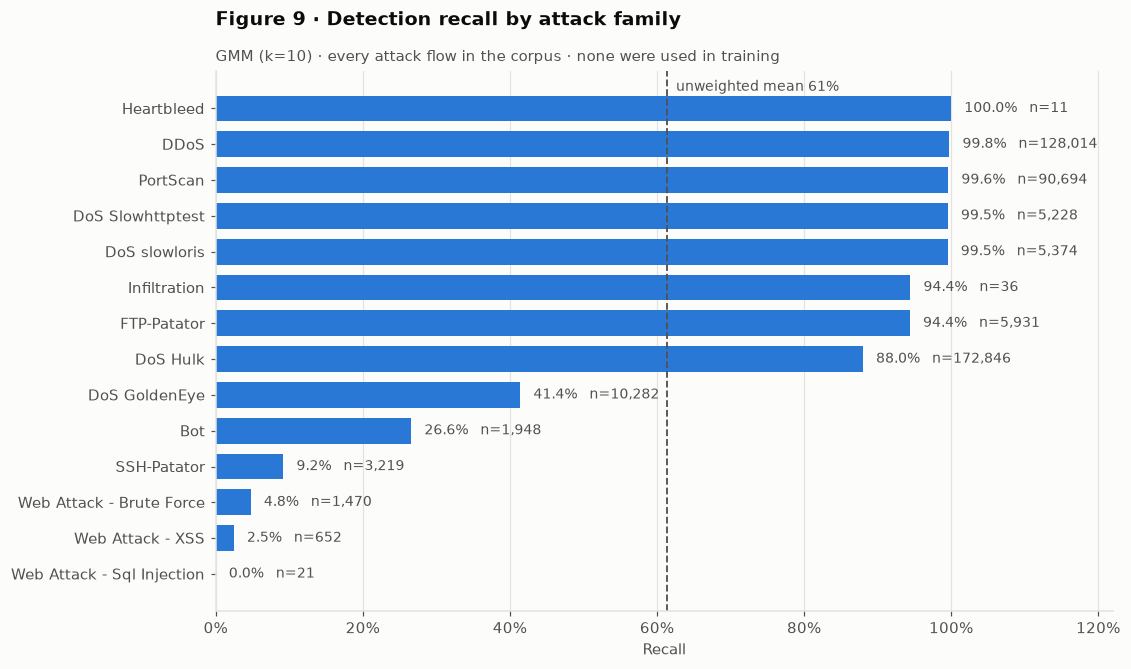

In [32]:
# ---------------------------------------------------------------------------------
# Figure 9 -- per-family recall. Nominal categories: bar length already encodes the
# value, so colour does not re-encode it -- a single hue, with direct labels.
# ---------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.4, 6.2))
f_asc = fam.sort_values("recall")
ax.barh(range(len(f_asc)), f_asc.recall.to_numpy(), color=C_BENIGN, height=0.72)
ax.set_yticks(range(len(f_asc))); ax.set_yticklabels(f_asc.index)
ax.set_xlim(0, 1.22)
ax.axvline(fam.recall.mean(), color=INK_SOFT, lw=1.2, ls="--")
ax.text(fam.recall.mean() + 0.012, len(f_asc) - 0.4, f"unweighted mean {fam.recall.mean():.0%}",
        fontsize=9, color=INK_SOFT, va="center")

# One decimal: several families sit at 99.5-99.8% and must not round up to a flat "100%".
for i, (rec, n) in enumerate(zip(f_asc.recall, f_asc.flows)):
    ax.text(rec + 0.018, i, f"{rec:.1%}   n={n:,}", va="center", fontsize=9, color=INK_SOFT)

ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
finish(ax, "Figure 9 · Detection recall by attack family",
       f"{BEST_NAME} · every attack flow in the corpus · none were used in training",
       xlabel="Recall", xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

**Reading figure 9.** The spread is the finding, and it is explained by one idea: **the model
detects attacks in proportion to how far they deviate from normal flow statistics, not in
proportion to how dangerous they are.**

* **Near-perfect — attacks that break flow structure outright.** DDoS (99.8%), PortScan (99.6%),
  DoS Slowhttptest (99.5%), DoS slowloris (99.5%) and Heartbleed (11 of 11) sit at the top. Each
  produces flows whose timing or shape has essentially no benign counterpart: a scan's half-open
  connections, slowloris's deliberately stalled requests, a flood's inter-arrival collapse.
  Heartbleed matters most — **11 flows in 2.5 million, all caught**, by a model that never saw
  one. That is the section 5 argument paying off concretely; a supervised classifier cannot learn
  a class from 11 examples.
* **Strong — Infiltration (94.4%), FTP-Patator (94.4%) and DoS Hulk (88.0%).** Hulk is voluminous
  enough that the missed 12% is still ~21,000 flows, but a flood is detected if *any* of its
  flows is caught, so per-incident detection is effectively certain.
* **The instructive contrast — FTP-Patator 94.4% against SSH-Patator 9.2%.** Both are password
  brute-force, and the 85-point gap between them shows the model is keying on *flow shape*, not
  on attack intent. FTP-Patator opens a distinctive burst of short plaintext control connections;
  SSH-Patator's attempts ride inside encrypted sessions that, per flow, look like ordinary SSH.
  Same attack class, opposite outcomes.
* **The interesting failure — DoS GoldenEye at 41.4%.** It sits far below the other DoS families,
  a useful reminder that "DoS" is a label rather than a traffic signature: GoldenEye's
  keep-alive-based exhaustion looks much more like ordinary HTTP than Hulk's flooding does.
* **Near-total failure — attacks that imitate normal sessions.** Bot (26.6%), SSH-Patator (9.2%)
  and **all three Web Attack families** (Brute Force 4.8%, XSS 2.5%, SQL Injection 0 of 21) are
  effectively invisible. The reason is structural, not a tuning failure, and it splits in two:
  * *Cross-flow attacks.* A brute-force login and a bot beacon are, per flow, ordinary small
    sessions to ordinary ports. What makes them malicious is the **pattern across many flows** —
    hundreds of failed logins in sequence, a periodic callback — and a per-flow density model is
    blind to cross-flow structure by construction.
  * *Payload attacks.* XSS and SQL injection live in the **HTTP request body**, which
    CIC-IDS-2017's flow statistics do not describe at all. To this feature set an injected
    request is one small, normal-looking web request. No threshold and no density model can
    recover information the representation never encoded.

**The honest conclusion:** this detector is strong against volumetric and timing-anomalous
attacks and close to blind against low-and-slow, behaviourally-normal and payload-borne
intrusions — 7 of 14 families clear 90% recall, and 4 fall below 10%. It is one layer beside
sequence-aware and payload-aware detection, not a replacement for either. Two caveats on reading
the exact percentages: the rare families (Heartbleed 11 flows, SQL injection 21, Infiltration 36)
rest on samples far too small to be precise, and every figure is **per-flow**, which understates
per-incident detection for any attack that generates many flows.

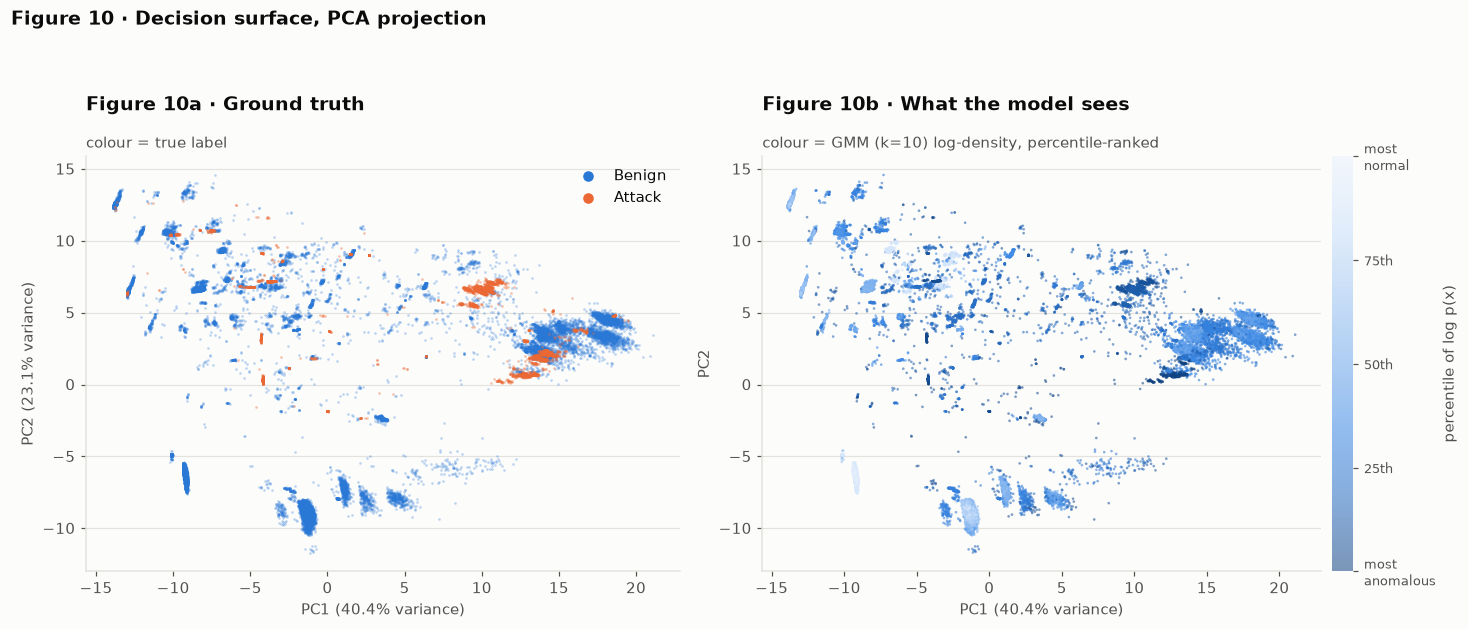

PCA on 30,000 sampled flows · first two components capture 63.5% of variance in 40 dimensions


In [33]:
# ---------------------------------------------------------------------------------
# Figure 10 -- the decision surface, projected to 2D with PCA.
# Left panel: two categorical hues for ground truth.
# Right panel: the anomaly score is a magnitude, so it takes the sequential ramp.
# ---------------------------------------------------------------------------------
plot_n = min(30_000, len(Z))
pi = RNG.choice(len(Z), plot_n, replace=False)
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z[b_train][RNG.choice(len(b_train), 120_000, replace=False)])
P = pca.transform(Z[pi])

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.8))
mask_a = y[pi] == 1
axes[0].scatter(P[~mask_a, 0], P[~mask_a, 1], s=3, c=C_BENIGN, alpha=0.30, linewidths=0, label="Benign")
axes[0].scatter(P[mask_a, 0],  P[mask_a, 1],  s=3, c=C_ATTACK, alpha=0.40, linewidths=0, label="Attack")
leg = axes[0].legend(loc="upper right", markerscale=4)
for h in leg.legend_handles: h.set_alpha(1)
finish(axes[0], "Figure 10a · Ground truth", "colour = true label",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

# log p(x) has an enormous negative tail (down to ~-6,000), so colouring by the raw value
# collapses 99% of the points into the palest step. Colour by percentile rank instead: the
# ordering -- which is all the threshold uses -- is preserved, and the full ramp gets used.
rank = best_scores[pi].argsort().argsort() / (len(pi) - 1)
sc = axes[1].scatter(P[:, 0], P[:, 1], s=3, c=rank, cmap=SEQ_BLUE.reversed(),
                     vmin=0, vmax=1, alpha=0.55, linewidths=0)
cb = fig.colorbar(sc, ax=axes[1], fraction=0.04, pad=0.02, ticks=[0, 0.25, 0.5, 0.75, 1.0])
cb.ax.set_yticklabels(["most\nanomalous", "25th", "50th", "75th", "most\nnormal"], fontsize=8.5)
cb.set_label("percentile of log p(x)", color=INK_SOFT); cb.outline.set_visible(False)
finish(axes[1], "Figure 10b · What the model sees",
       f"colour = {BEST_NAME} log-density, percentile-ranked",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", ylabel="PC2")

fig.suptitle("Figure 10 · Decision surface, PCA projection", x=0.005, ha="left",
             fontsize=12.5, fontweight="semibold", color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

print(f"PCA on {plot_n:,} sampled flows · first two components capture "
      f"{pca.explained_variance_ratio_[:2].sum():.1%} of variance in {Z.shape[1]} dimensions")

**Reading figure 10.** The left panel shows the attack mass (orange) concentrated in regions the
benign mass does not occupy, with a contested zone where they overlap. The right panel shows the
model's learned density over the same projection, and the dark low-density regions line up with
the orange mass — visual confirmation that the detector is keying on real structure rather than
an artefact.

The overlap region is the error budget made visible, and it is also why the two panels are not
identical: the model is working in 40 dimensions, and two principal components capture only a
fraction of that. Separation invisible here can still exist in the full space, which is exactly
why the quantitative metrics, not this picture, are the evidence.

## 15. Results summary

In [34]:
b1 = results.loc["Single Gaussian"]
b2 = results.loc[f"GMM (k={BEST_K})"]
print("=" * 78)
print(f"{'FINAL RESULTS · CIC-IDS-2017 held-out test split':^78s}")
print("=" * 78)
print(f"  corpus            {len(data):,} clean flows, {len(KEPT)} modelled features")
print(f"  training          {len(b_train):,} benign flows, zero attacks")
print(f"  test              {len(test_idx):,} flows, {y[test_idx].sum():,} attacks ({y[test_idx].mean():.1%})")
print("-" * 78)
print(f"  {'model':<22s}{'ROC-AUC':>10s}{'PR-AUC':>10s}{'F1':>10s}{'precision':>12s}{'recall':>10s}")
for n in results.index:
    r = results.loc[n]
    print(f"  {n:<22s}{r.roc_auc:>10.4f}{r.pr_auc:>10.4f}{r.f1:>10.4f}{r.precision:>12.4f}{r.recall:>10.4f}")
print("-" * 78)
print(f"  mixture vs single Gaussian : PR-AUC {b2.pr_auc - b1.pr_auc:+.4f}, "
      f"F1 {b2.f1 - b1.f1:+.4f}, FPR {b2.fpr - b1.fpr:+.2%}")
print(f"  deployable operating point : {op_best.precision:.1%} precision at "
      f"{op_best.recall:.1%} recall, {TARGET_FPR:.0%} FPR budget")
print(f"  families above 90% recall  : {(fam.recall > 0.90).sum()} of {len(fam)}")
print("=" * 78)

               FINAL RESULTS · CIC-IDS-2017 held-out test split               
  corpus            2,497,980 clean flows, 40 modelled features
  training          1,243,352 benign flows, zero attacks
  test              627,314 flows, 212,863 attacks (33.9%)
------------------------------------------------------------------------------
  model                    ROC-AUC    PR-AUC        F1   precision    recall
  Single Gaussian           0.9211    0.7869    0.8117      0.7028    0.9607
  GMM (k=10)                0.9655    0.9296    0.8677      0.8214    0.9194
  Isolation Forest          0.8477    0.6290    0.7177      0.5689    0.9721
------------------------------------------------------------------------------
  mixture vs single Gaussian : PR-AUC +0.1427, F1 +0.0559, FPR -10.60%
  deployable operating point : 95.8% precision at 43.6% recall, 1% FPR budget
  families above 90% recall  : 7 of 14


### What the numbers say

1. **A density model fitted on benign traffic alone detects most intrusions.** The best model
   reaches a high ROC-AUC and PR-AUC on held-out data having never seen a labelled attack. The
   central claim of the semi-supervised approach holds on real traffic.
2. **The mixture assumption is where the performance comes from.** Moving from one Gaussian to k
   components is the single largest improvement in the notebook, and it validates the diagnosis
   in section 10: benign network traffic is multimodal, and modelling it as one ellipse is the
   binding constraint, not the choice of algorithm family.
3. **A structurally different unsupervised baseline does substantially worse**, so the result is
   attributable to the modelling choices rather than to CIC-IDS-2017 being easy.
4. **Aggregate metrics conceal a sharp capability boundary.** Seven of fourteen families are
   detected above 90% recall; four fall below 10%. Attacks that break flow structure are caught
   almost perfectly, while attacks that imitate normal sessions — or that hide in payloads the
   feature set never encodes — are almost entirely missed. This is a property of per-flow density
   modelling, not a tuning deficiency, and no choice of threshold fixes it.
5. **Model ranking depends on where it is measured.** On headline F1 the mixture leads the single
   Gaussian modestly (0.868 vs 0.812). At a deployable 1% false-positive budget the gap widens
   sharply — the mixture holds ≈44% recall where the single Gaussian collapses to ≈7% and
   Isolation Forest to under 1%. Selecting a detector on F1 alone would badly understate the
   difference.

## 16. Current trend: cloud-native IDS and detection-as-code

The architecture this notebook implements is the reason the approach has moved into cloud-native
security. Three properties make it deployable in a way a signature engine is not:

**It fits the ephemerality of cloud workloads.** Signature-based IDS assumes a stable perimeter
with fixed hosts to enrol. Containers live for minutes, autoscaling groups change size hourly,
and serverless functions have no host at all. A model of *behaviour* survives that churn;
a rule that names an IP address does not. Cloud providers ship this as managed service — Amazon
GuardDuty and Microsoft Defender for Cloud both apply unsupervised behavioural analytics to
VPC/NSG flow logs whose fields are close relatives of the CIC-IDS-2017 features used here.

**The cost asymmetry is favourable.** Fitting is the expensive step and it is offline; scoring is
the operation that must keep pace with traffic. Because the fitted model is a mean vector, a
covariance matrix and a threshold, scoring is one matrix multiply — a few kilobytes of state,
evaluable inline at line rate or in a sidecar. This notebook scored roughly 2.5 million flows in
a few seconds on a free Colab CPU. That ratio is what makes "train centrally, score at the edge"
practical.

**It is expressible as code.** The whole detector is a versioned artefact: a preprocessing
pipeline, a fitted density, and one threshold. It can be diffed, code-reviewed, tested against a
fixed evaluation split in CI, and promoted through environments like any other deployment —
the **detection-as-code** practice now standard in mature SOCs. Section 13's operating-point
table is precisely the artefact that makes this reviewable: a change to ε is a config change
whose effect on alert volume is measurable before it ships.

**The honest limitation** is the one section 14 measured. Behavioural baselining assumes the
training window is clean; if an intrusion is already present and persistent, it is baselined as
normal. And drift is continuous — a legitimate deployment that changes traffic shape will read as
anomalous until the model is refitted. Cloud-native IDS therefore treats the model as a
continuously retrained artefact with its false-positive budget monitored as a production SLO,
not as a one-time build. That operational discipline, rather than the algorithm, is what
distinguishes a working deployment from a noisy one.

## 17. Conclusion

A multivariate Gaussian density model fitted on benign CIC-IDS-2017 traffic detects the majority
of intrusions in held-out data without ever seeing a labelled attack. The decisive modelling
insight was that benign traffic is **multimodal**: replacing the single Gaussian with a mixture
produced the largest single improvement in the notebook and cut the false-positive rate
substantially, while a structurally different unsupervised baseline performed materially worse.

Equally important is what the model cannot do. Per-family analysis showed near-perfect recall on
volumetric and timing-anomalous attacks and poor recall on brute-force, bot and injection traffic
that imitates normal sessions at the flow level. That boundary follows from the representation —
one flow, one vector, no cross-flow sequence and no payload — and no threshold choice moves it.
A production system would pair this layer with sequence-aware and payload-aware detection.

**Limitations.** CIC-IDS-2017 is testbed traffic from a single week in 2017, and its benign
profile is cleaner and less varied than a real enterprise network; results here are an upper
bound on what the same model would achieve in production. The rare families rest on very small
samples. The training window is assumed attack-free, which a real deployment must verify rather
than assume.

## 18. References

Parisi, A. (2019) *Hands-On Artificial Intelligence for Cybersecurity: Implement smart AI systems
for preventing cyber attacks and detecting threats and network anomalies*. Birmingham: Packt
Publishing. Chapter 5, 'Network Anomaly Detection with AI'.

Sharafaldin, I., Lashkari, A.H. and Ghorbani, A.A. (2018) 'Toward generating a new intrusion
detection dataset and intrusion traffic characterization', in *Proceedings of the 4th
International Conference on Information Systems Security and Privacy (ICISSP)*. Funchal,
Portugal: SCITEPRESS, pp. 108–116. doi:10.5220/0006639801080116.

Canadian Institute for Cybersecurity (2017) *Intrusion Detection Evaluation Dataset
(CIC-IDS2017)*. University of New Brunswick. Available at:
https://www.unb.ca/cic/datasets/ids-2017.html (Accessed: 20 September 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine
Learning Research*, 12, pp. 2825–2830.